# 04 · optimizer의 계산

**이번 질문:** 같은 기울기를 받아도 SGD·Momentum·RMSProp·Adam은 왜 다른 파라미터를 만들까요?

01번의 갱신은 "기울기 반대 방향으로 학습률만큼" 하나뿐이었습니다. 실제 학습에서는 기울기를 **일부 데이터(미니배치)**로 계산해 잡음이 섞이고,
방향마다 가파른 정도가 달라 한 학습률로는 어떤 방향은 튀고 어떤 방향은 느립니다. 이 두 문제를 다루는 갱신 규칙들이 optimizer입니다.
[01](01_gradients_and_learning.ipynb)의 미분·갱신을 출발점으로 삼고, [02](02_probability_and_losses.ipynb)의 기댓값과 [03](03_perceptron_to_mlp.ipynb)의 역전파를 연결합니다.

> **용어** · **optimizer**: 기울기를 받아 파라미터를 **어떻게 얼마나** 바꿀지 정하는 갱신 규칙. 기울기 계산(역전파)과는 별개의 단계입니다.

### 읽는 법

| 표시 | 뜻 | 어떻게 읽나 |
|---|---|---|
| 🔑 **핵심** | 수식·규칙·코드. 이 노트북이 가르치려는 것 | 남에게 설명할 수 있을 때까지 읽고, 코드를 가리고 다시 써 봅니다 |
| 🔍 **확인** | 검산 결과와 그림의 해석 | 실행해서 눈으로 보고 넘어갑니다. 외울 것은 없습니다 |
| 📎 **참고** | 배경 지식, 환경, 용어의 유래 | 처음 읽을 때는 건너뛰어도 됩니다 |
| ✏️ **연습** | 직접 바꿔 보는 문제 | 손으로 먼저 예상한 뒤 실행합니다 |

새 용어는 처음 나오는 자리에서 **용어** 상자로 한 줄씩 풀이합니다.

**이 노트북에서 반드시 가져갈 세 가지**

1. 기울기는 방향이고 optimizer는 "얼마나·어떻게"입니다. 학습률이 곡률에 비해 크면($\eta>2/a$) 손실이 커지며 발산합니다.
2. 미니배치 기울기는 전체 기울기의 잡음 섞인 추정입니다(01b). 기댓값은 같고 잡음은 배치 크기의 제곱근에 반비례해 줄어듭니다.
3. Momentum은 방향을 기억하고(`v`), RMSProp은 좌표별 크기를 기억하고(`s`), Adam은 둘 다 기억하며 초기 편향을 보정합니다. 이 상태를 스텝 사이에 유지합니다.

[전체 학습 경로](../../docs/CURRICULUM.md) · [글 규칙](../../docs/WRITING.md) · [그림 설계](../../docs/DESIGN.md) · [그림 보조 코드](../../src/utils/optimizer_plots.py)


In [1]:
# 준비 셀: 실행만 하고 넘어가도 됩니다.
# 1) 프로젝트 루트를 import 경로에 넣습니다. 노트북을 어느 폴더에서 열어도 src/를 찾기 위해서입니다.
import sys
from pathlib import Path
project_root = next(p for p in (Path.cwd(), *Path.cwd().parents)          # 현재 폴더부터 위로 올라가며
                    if (p / "src" / "utils" / "plotting.py").is_file())    # src/utils/plotting.py가 있는 첫 폴더를 고릅니다
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# 2) NumPy, 수치미분 검사기(1절), 데이터 로더, 이 노트북의 그림 함수(src/utils/optimizer_plots.py), 연습 검사 도우미
import numpy as np
from src.utils import setup_plots
from src import check_function
from src.data.mnist import load_mnist, load_examples
from src.utils.optimizer_plots import (
    plot_step_size_parabola, plot_gd_zigzag, plot_state_bars,
    plot_bias_correction, plot_optimizer_landscape, plot_optimizer_templates,
    plot_batch_gradients, plot_moments, plot_optimizer_paths,
    plot_regression_runs, plot_initialization, plot_schedule,
)
from src.utils import run_check

# 3) 그림 설정. 배열 출력은 소수 6자리로 줄여 읽기 쉽게 합니다.
setup_plots()
np.set_printoptions(precision=6, suppress=True)
print("NumPy", np.__version__, "· optimizer 준비 완료")

NumPy 2.4.6 · optimizer 준비 완료


### 📎 이 노트북의 예시: 이차 목적, 과일 회귀, MNIST

- **이차 목적** $J(\theta)=\tfrac12(\theta_0^2+20\theta_1^2)$. 두 방향의 가파른 정도가 1과 20으로 달라, 학습률 하나로는 한쪽이 튀는 문제를 작게 보여 줍니다.
- **과일 회귀.** 붉기 $x$에서 당도 $y=1.7x-0.4+$잡음을 맞히는 직선. 8절에서 네 optimizer를 같은 배치 순서로 비교합니다.
- **MNIST.** 학습 집합 앞 5,000장으로 "7이면 1"을 맞히는 선형 회귀입니다. 8절에서 optimizer별로 가중치 이미지가 자라나는 속도를 봅니다. 미니배치 자체는 [01b](01b_minibatch.ipynb)에서 다뤘습니다.
  아래 셀은 실행만 하고 넘어가도 됩니다.

> **코드**
>
> - `_`: 함수가 돌려준 값 중 쓰지 않는 것을 받아 버리는 관례상의 이름입니다.
> - `(mnist_y_all[:5000] == 7).astype(float)`: 비교 결과 True/False를 1.0/0.0으로 바꾼 정답 `(5000,)`.
> - `np.column_stack([mnist_X, np.ones(len(mnist_X))])`: 이미지 `(5000, 784)` 옆에 1로 된 열을 붙여 `(5000, 785)`. 마지막 열의 계수가 편향이라, 가중치와 편향을 벡터 하나 θ로 다룰 수 있습니다(2절).

In [2]:
mnist_examples, mnist_labels = load_examples(download=True)         # (10, 28, 28), (10,): 고정 예시 (이 노트북에서는 그림에만 씀)
mnist_X_all, mnist_y_all, _, _ = load_mnist()                       # (60000, 784), (60000,). 시험용 두 값은 안 쓰므로 _ 로 버립니다
mnist_X = mnist_X_all[:5000]                                        # (5000, 784): 학습용 앞 5,000장
mnist_T = (mnist_y_all[:5000] == 7).astype(float)                   # (5000,): 7이면 1
mnist_F = np.column_stack([mnist_X, np.ones(len(mnist_X))])         # (5000, 785): 마지막 열 1은 편향 자리
print("MNIST 특성", mnist_F.shape, "· 정답", mnist_T.shape)

MNIST 특성 (5000, 785) · 정답 (5000,)


## 🔑 1. 기울기와 업데이트를 구분합니다

**이 절에서 가져갈 것:** 기울기 $g$는 손실이 가장 빨리 커지는 방향이고, 실제 이동량 $\theta_{t+1}-\theta_t$는 optimizer가 정합니다. 학습률이 곡률에 비해 크면 발산합니다.

> **용어**
>
> - **파라미터 벡터** $\theta$: 모든 가중치와 편향을 한 벡터로 모은 것. 기울기 $g=\nabla_\theta J$도 같은 shape.
> - **곡률(curvature)**: 어떤 방향으로 움직일 때 기울기가 얼마나 빨리 변하는가. 이차식 $\tfrac12 a w^2$에서는 $a$. 클수록 가파른 골짜기.

가장 기본적인 경사하강은 $\theta_{t+1}=\theta_t-\eta g_t$입니다.
예를 들어 $J(\theta)=\tfrac12(\theta_0^2+20\theta_1^2)$이면 $g=(\theta_0,20\theta_1)$입니다.
두 번째 방향은 같은 변화에도 기울기가 더 빨리 변합니다. 이 곡률이 각 방향의 이차미분인 1과 20입니다.

1차원 $J(w)=aw^2/2$의 갱신을 정리하면 $w_{t+1}=(1-\eta a)w_t$입니다.
$w_t$의 크기가 줄려면 $|1-\eta a|<1$, 즉 $0<\eta<2/a$여야 합니다.
📎 이 양의 이차식에서 얻은 조건이 모든 비선형 신경망에 그대로 적용되는 것은 아닙니다.

아래는 $a=20$에서 학습률 세 가지로 8스텝 움직인 자취입니다.

> **코드**
>
> - `for eta_1d, name in [(0.03, "…"), …]`: (학습률, 그림 이름) 쌍의 목록을 돌며 두 이름에 한 번에 풀어 받습니다.
> - `w_seq[-1]`: 목록의 마지막 원소, 곧 지금 위치. 새 위치를 `append`로 뒤에 붙여 자취를 만듭니다.
> - `{name: … for name, seq in paths_1d.items()}`: 사전의 (키, 값)마다 새 값을 계산해 사전으로 모읍니다(사전 컴프리헨션).

In [3]:
a_curv = 20.0                                                        # 곡률 a. J(w) = a w²/2
w_grid = np.linspace(-1.6, 1.6, 200)                                 # (200,): 그림용 w 좌표
J_grid = 0.5 * a_curv * w_grid ** 2                                  # (200,): 포물선
paths_1d = {}                                                        # 그림 이름 → 8스텝 자취 (9,)
for eta_1d, name in [(0.03, "$\\eta=0.03 < 1/a$"), (0.095, "$1/a < \\eta=0.095 < 2/a$"), (0.11, "$\\eta=0.11 > 2/a$")]:
    w_seq = [1.0]                                                    # w = 1에서 출발
    for _ in range(8):
        w_seq.append(w_seq[-1] - eta_1d * a_curv * w_seq[-1])       # w ← w − η·a·w = (1 − ηa)·w
    paths_1d[name] = np.array(w_seq)
print({name: np.round(seq[-1], 3) for name, seq in paths_1d.items()})   # 8스텝 뒤의 w

{'$\\eta=0.03 < 1/a$': np.float64(0.001), '$1/a < \\eta=0.095 < 2/a$': np.float64(0.43), '$\\eta=0.11 > 2/a$': np.float64(4.3)}


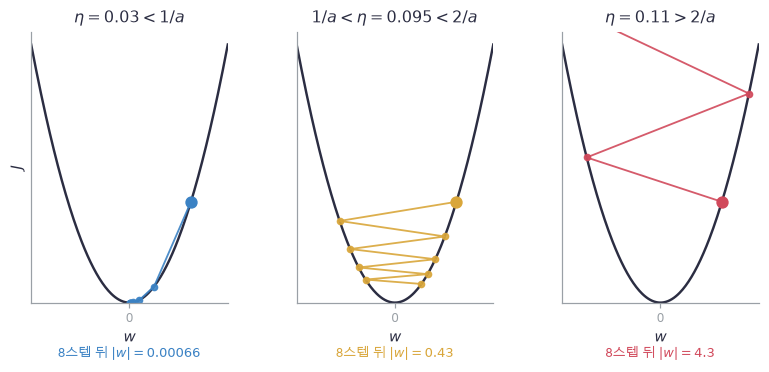

In [4]:
plot_step_size_parabola(w_grid, J_grid, paths_1d, a_curv)

🔍 **확인** · 같은 기울기 공식인데 학습률만 달라도 자취가 전혀 다릅니다. 왼쪽은 한쪽에서 조용히 내려가고, 가운데는 골짜기를 좌우로 건너뛰며 줄어들고, 오른쪽은 건너뛸 때마다 더 멀어집니다.
경계는 $\eta a=2$입니다. 곡률 $a$가 큰 방향일수록 허용되는 학습률이 작으므로, 뒤에서 방향마다 보폭을 다르게 주는 규칙(RMSProp·Adam)이 나옵니다.

In [5]:
def quadratic(theta):
    """이차 목적 J(θ) = ½(θ₀² + 20θ₁²)와 그 기울기 ∇J = (θ₀, 20θ₁). theta: (2,) → (J: 숫자, g: (2,))."""
    curvature = np.array([1., 20.])                     # (2,): 방향별 곡률
    return 0.5 * np.sum(curvature * theta**2), curvature * theta

In [6]:
theta_start = np.array([3., 1.])                        # (2,): 시작점
start_loss, start_gradient = quadratic(theta_start)
np.testing.assert_allclose([start_loss, *start_gradient], [14.5, 3., 20.])   # 검산: ½(9 + 20) = 14.5, g = (3, 20)


def quadratic_objective(theta):
    """검사기용: 목적값 J만. theta: (2,) → 숫자 하나."""
    return np.array(quadratic(theta)[0])


def quadratic_backward(dout, theta):
    """검사기용: 손으로 유도한 ∇J × 상류 기울기 dout. → (2,)."""
    return dout * quadratic(theta)[1]


quadratic_error = check_function(quadratic_objective, quadratic_backward, theta_start,
                                 dout=np.array(1.), verbose=True, name="이차 목적의 기울기")   # 중심차분과 대조 (01번 5절)
for rate in (0.05, 0.11):                               # 학습률 두 가지로 한 스텝: 0.11은 2/a = 0.1을 넘어 θ₁이 커집니다
    updated = theta_start - rate * start_gradient
    print(f"η={rate}: θ={updated}, J={quadratic(updated)[0]:.6f}")

[gradcheck] 이차 목적의 기울기
  ok   dx  rel_err = 2.097e-11
η=0.05: θ=[2.85 0.  ], J=4.061250
η=0.11: θ=[ 2.67 -1.2 ], J=17.964450


### ✏️ 연습 1 · 포물선 위의 경사하강

연습은 코딩 테스트처럼 **함수 뼈대가 미리 있고 핵심 한두 줄만 비어 있습니다.** `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓴 뒤, 셀을 실행하고 바로 아래 검사 셀을 실행하세요. 아직 채우지 않았으면 안내문만 나오고, 값이 다르면 "손계산과 다릅니다"가 나옵니다. 막히면 그 아래 "정답 보기"를 펼칩니다.

1차원 $J(w)=aw^2/2$에서 기울기는 $g=aw$입니다. 시작점 `w0`에서 `steps`번 갱신한 자취 `path` `(steps+1,)`을 채우는 반복문 안 한 줄을 쓰세요. 검사는 $a=20$에서 학습률을 경계 $2/a=0.1$의 아래·위·정확히로 바꿔 가며 줄어드는지, 부호를 바꾸며 커지는지, 크기가 그대로인지 봅니다.

In [7]:
def exercise_parabola_path(w0, curvature, learning_rate, steps):
    """연습 1: J(w) = a w²/2에서 경사하강 steps번. w0, curvature(a), learning_rate(η): 숫자, steps: 정수 → 자취 (steps+1,)."""
    assert curvature > 0, "곡률 a는 양수여야 합니다"
    path = np.zeros(steps + 1)                     # (steps+1,): 자취. 0으로 채워 두었으니 반복문이 모두 덮어써야 합니다
    path[0] = w0                                   # 시작점
    for t in range(steps):
        ### 이 주석 아래에 다음을 구현하세요.
        ### 구현할 내용: 기울기 g = a·w를 학습률만큼 뺀 다음 위치 path[t + 1]
        ### 힌트: 1절 그림 셀의 w_seq.append(...) 안의 식과 같습니다. 정리하면 (1 − ηa)·w라서, ηa가 2를 넘으면 부호가 바뀌며 커집니다.
        raise NotImplementedError
    return path

In [8]:
def check_parabola_path(candidate):
    """a = 20에서 학습률 세 가지(경계 2/a = 0.1의 아래·위·정확히)와 1절 그림의 자취로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: a_curv, paths_1d (1절 그림 셀)
    actual = candidate(1.0, 20.0, 0.03, 3)
    assert actual.shape == (4,), f"자취는 시작점을 포함해 (steps+1,) = (4,)이어야 하는데 {actual.shape}입니다"
    np.testing.assert_allclose(actual, [1., 0.4, 0.16, 0.064])                     # 검산: 1 − ηa = 0.4배씩 줄어듦
    np.testing.assert_allclose(candidate(1.0, 20.0, 0.11, 2), [1., -1.2, 1.44])    # 검산: 1 − ηa = −1.2배. 부호가 바뀌며 커짐 (η > 2/a)
    np.testing.assert_allclose(candidate(1.0, 20.0, 0.1, 2), [1., -1., 1.])        # 검산: 경계 η = 2/a에서는 크기가 그대로
    np.testing.assert_allclose(candidate(1.0, a_curv, 0.03, 8), paths_1d["$\\eta=0.03 < 1/a$"])   # 검산: 1절 그림의 왼쪽 자취 9개
    print("포물선 위의 경사하강: 손계산과 일치합니다.")

run_check(check_parabola_path, exercise_parabola_path, hint="path[t + 1] = path[t] - learning_rate * curvature * path[t]")

☐ exercise_parabola_path: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: path[t + 1] = path[t] - learning_rate * curvature * path[t]


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
path[t + 1] = path[t] - learning_rate * curvature * path[t]
```

</details>

## 🔍 2. 미니배치 복습: 어떤 표본의 기울기를 평균낼까요?

[01b](01b_minibatch.ipynb)에서 본 내용의 요약입니다. 회귀의 절반 MSE를 $J(\theta)=\frac1N\sum_n\ell_n(\theta)$로 놓으면
$\nabla J=\frac1N\sum_n\nabla\ell_n$입니다. 같은 $\theta$에서 계산한 **각 표본의 기울기를 평균**낸 것이고,
미니배치 기울기는 그중 $B$개만 평균낸 추정치입니다. 기댓값은 같고 잡음의 표준편차는 $1/\sqrt B$입니다.

회귀 입력을 $F_n=[x_n,1]$, 파라미터를 $\theta=[w,b]$로 모으면 $\hat y=F\theta$, $r=\hat y-y$이며, 표본 기울기는 $r_nF_n$, 전체 기울기는 $F^\top r/N$입니다.
`F.shape=(N,2)`, `y.shape=(N,)`, `theta.shape=(2,)`입니다. 아래 두 함수는 이 노트북 전체에서 씁니다.

> **용어** · **에폭(epoch)**은 학습 데이터를 한 번 모두 사용하는 단위, **스텝(step)**은 파라미터를 한 번 갱신하는 단위입니다. 배치 크기가 $B$이면 한 에폭의 스텝 수는 $\lceil N/B\rceil$이며 마지막 배치는 작을 수 있습니다.

> **코드**
>
> - `(F @ theta - y)[:, None] * F`: 잔차 `(N,)`을 `(N, 1)`로 세워 행마다 곱하면 표본별 기울기 `r_n F_n`이 행이 되는 `(N, 2)`.
> - `order[start:start+batch_size]`(슬라이스)와 `range(0, size, batch_size)`: 섞은 번호를 앞에서부터 B개씩 자릅니다. 끝을 넘으면 있는 만큼만 나와 마지막 배치가 짧아집니다(01b 3절).

In [9]:
def regression_loss_gradient(features, targets, theta):
    """회귀의 절반 MSE와 기울기: J = (1/2N) Σ r_n², ∇J = Fᵀ r / N, r = Fθ − y.
    features: (N, 2), targets: (N,), theta: (2,) → (J: 숫자, g: (2,))."""
    residual = features @ theta - targets                   # (N,): 예측 − 정답
    return 0.5 * np.mean(residual**2), features.T @ residual / len(targets)


def epoch_batches(size, batch_size, rng):
    """한 에폭의 배치 인덱스 목록 (01b 3절): 0…size−1을 섞은 뒤 batch_size개씩 끊습니다. 마지막 것만 짧을 수 있습니다."""
    assert batch_size > 0, "batch_size는 1 이상이어야 합니다"
    order = rng.permutation(size)                           # (size,): 표본 번호를 무작위 순서로
    return [order[start:start+batch_size] for start in range(0, size, batch_size)]

In [10]:
x_small = np.array([-2., -1., 0., 1., 2., 3.])          # (6,): 표본 6개의 입력
F_small = np.column_stack([x_small, np.ones(len(x_small))])   # (6, 2): [x, 1]
y_small = 2*x_small - 0.3                                # (6,): 잡음 없는 정답
theta_small = np.array([0., 0.])                         # (2,): 파라미터를 고정
_, full_gradient = regression_loss_gradient(F_small, y_small, theta_small)   # (2,): 전체 기울기. 손실은 안 씀
per_sample = (F_small @ theta_small - y_small)[:, None] * F_small            # (6, 2): 표본별 기울기 r_n F_n
np.testing.assert_allclose(full_gradient, per_sample.mean(axis=0))          # 검산: 전체 기울기 = 표본 기울기의 평균
batches = epoch_batches(len(x_small), 4, np.random.default_rng(8))          # 6개를 4개씩 → 크기 [4, 2]
assert [len(batch) for batch in batches] == [4, 2], "배치 크기는 [4, 2]여야 합니다"
np.testing.assert_array_equal(np.sort(np.concatenate(batches)), np.arange(6))   # 검산: 모든 표본이 한 번씩
weighted_gradient = np.zeros(2)                          # 배치 기울기를 실제 크기로 가중한 합
unweighted_gradient = np.zeros(2)                        # 배치 수로 단순 평균한 것 (틀린 방식)
for batch in batches:
    gradient = regression_loss_gradient(F_small[batch], y_small[batch], theta_small)[1]   # 이 배치만의 기울기
    weighted_gradient += len(batch) / len(x_small) * gradient    # 배치 크기 / N 을 곱해 더함
    unweighted_gradient += gradient / len(batches)
np.testing.assert_allclose(weighted_gradient, full_gradient)     # 검산: 가중 합 = 전체 기울기
print("전체 기울기", full_gradient)
print("배치 평균에 표본 수 가중치 적용", weighted_gradient)
print("크기 다른 배치 평균끼리 단순 평균", unweighted_gradient)

전체 기울기 [-6.183333 -0.7     ]
배치 평균에 표본 수 가중치 적용 [-6.183333 -0.7     ]
크기 다른 배치 평균끼리 단순 평균 [-5.5625 -0.95  ]


🔍 **확인** · 위 항등식은 **같은 파라미터를 고정한 채** 계산한 결과입니다. 배치를 실제 크기로 평균내야(가중 합) 전체 기울기가 나오고, 배치 수로 단순 평균하면 마지막 작은 배치가 과대평가됩니다.
실제 미니배치 학습은 배치마다 파라미터를 바꾸므로 한 에폭의 갱신은 전체 기울기로 한 번 갱신하는 것과 다릅니다.

## 🔑 3. SGD: 현재 배치의 기울기를 그대로 사용합니다

**이 절에서 가져갈 것:** SGD는 01번의 갱신 그대로입니다. 기억하는 상태가 없어서, 가파른 방향에서는 튀고 완만한 방향에서는 느립니다.

> **용어**
>
> - **SGD(stochastic gradient descent, 확률적 경사하강)**: 미니배치 기울기로 $\theta\leftarrow\theta-\eta g$를 반복하는 것. "확률적"은 배치를 무작위로 뽑는다는 뜻.
> - **상태(state)**: 업데이트 사이에 기억해 두는 값. SGD는 기록용 스텝 수 외에 기억하는 것이 없습니다.

$$\theta_{t+1}=\theta_t-\eta g_t.$$

아래 갱신 함수를 전체 데이터 기울기에 적용하면 full-batch gradient descent가 됩니다.
함수는 새 파라미터와 새 상태를 반환하며, 입력 배열을 직접 덮어쓰지 않습니다. 먼저 1절의 이차 목적에서 이 규칙이 어떻게 움직이는지 봅니다.

> **코드**
>
> - `state.get("t", 0)`: 사전에 키 `"t"`가 있으면 그 값, 없으면 0. 첫 스텝에는 빈 사전 `{}`이 들어오므로 0에서 시작합니다.
> - 갱신 함수는 `(새 파라미터, 새 상태 사전)` 두 개를 돌려주고, 부르는 쪽이 `theta, state = sgd_step(...)`으로 받아 다음 스텝에 다시 넣습니다.

In [11]:
theta_start = np.array([3., 1.])                                    # (2,): 1절과 같은 시작점
eta_gd = 0.08                                                       # 학습률. 세로 곡률 20에 대해 ηa = 1.6 < 2 (튀지만 줄어듦)
gd_path = [theta_start.copy()]                                      # 자취. 시작점부터
for _ in range(40):
    grad_here = np.array([1., 20.]) * gd_path[-1]                   # ∇J = (θ0, 20 θ1)
    gd_path.append(gd_path[-1] - eta_gd * grad_here)                # θ ← θ − η g
gd_path = np.array(gd_path)                                         # (41, 2)
xx, yy = np.meshgrid(np.linspace(-3.3, 3.3, 120), np.linspace(-1.3, 1.3, 120))   # (120, 120) 둘: 그림용 격자
surface = 0.5 * (xx ** 2 + 20 * yy ** 2)                            # (120, 120): 격자 위의 J
print("θ1은 매 스텝", 1 - eta_gd * 20, "배 · θ0은", 1 - eta_gd * 1, "배 · 40스텝 뒤", gd_path[-1].round(3))

θ1은 매 스텝 -0.6000000000000001 배 · θ0은 0.92 배 · 40스텝 뒤 [0.107 0.   ]


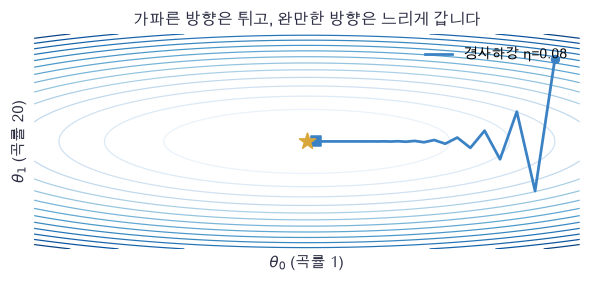

In [12]:
plot_gd_zigzag(xx, yy, surface, gd_path, eta_gd)

🔍 **확인** · 세로 방향(곡률 20)은 $1-0.08\times20=-0.6$배씩 부호를 바꾸며 튀고, 가로 방향(곡률 1)은 $0.92$배씩 천천히 움직입니다.
학습률을 키우면 세로가 발산하고, 줄이면 가로가 더 느려집니다. 학습률 하나로는 두 방향을 동시에 만족시킬 수 없습니다. 이것이 다음 세 optimizer의 출발점입니다.

In [13]:
def sgd_step(theta, gradient, state, learning_rate):
    """SGD 한 스텝: θ ← θ − η g. theta, gradient: 같은 모양, state: 사전 → (새 θ, {"t": 스텝 수})."""
    updated = theta - learning_rate * gradient
    return updated, {"t": state.get("t", 0) + 1}

In [14]:
initial = np.array([1., -2.])                            # (2,): 손계산용 시작 파라미터. 4–6절도 같은 값을 씁니다
g1 = np.array([2., -4.])                                 # (2,): 첫 스텝의 기울기
g2 = np.array([-1., 2.])                                 # (2,): 둘째 스텝의 기울기 (부호 반대)
sgd_first, sgd_state = sgd_step(initial, g1, {}, 0.1)   # 빈 상태 {}로 시작
sgd_second, sgd_state = sgd_step(sgd_first, g2, sgd_state, 0.1)
np.testing.assert_allclose(sgd_first, [0.8, -1.6])       # 검산: (1, −2) − 0.1·(2, −4)
np.testing.assert_allclose(sgd_second, [0.9, -1.8])      # 검산: (0.8, −1.6) − 0.1·(−1, 2)
np.testing.assert_array_equal(initial, [1., -2.])        # 검산: 입력 배열은 덮어쓰지 않음
print("SGD 1회", sgd_first, "2회", sgd_second, "상태", sgd_state)

SGD 1회 [ 0.8 -1.6] 2회 [ 0.9 -1.8] 상태 {'t': 2}


### ✏️ 연습 3 · 상태 없는 한 스텝

상태 처리와 반환은 미리 써 두었습니다. 기울기 반대 방향으로 학습률만큼 옮긴 `updated` 한 줄을 채우세요. 검사는 손계산 두 스텝에 더해, 기억하는 상태가 없으니 두 스텝의 결과가 두 기울기의 합을 한 번에 뺀 것과 같은지, 그리고 3절 그림의 시작점 $(3, 1)$에서 같은 한 줄이 곡률 20인 세로 좌표는 부호를 바꾸고 곡률 1인 가로 좌표는 조금만 옮기는지도 봅니다.

In [15]:
def exercise_sgd_step(theta, gradient, state, learning_rate):
    """연습 3: SGD 한 스텝. theta, gradient: 같은 모양, state: 사전 → (새 θ, {"t": 스텝 수})."""
    assert theta.shape == gradient.shape, "theta와 gradient는 같은 모양이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: 기울기 반대 방향으로 학습률만큼 옮긴 updated. theta를 직접 덮어쓰지 않습니다
    ### 힌트: 3절 sgd_step의 본문 한 줄, 01번의 갱신 θ ← θ − η g 그대로입니다. 기억할 상태가 없으니 state는 스텝 수만 세며, 그 줄은 아래 return에 미리 있습니다.
    raise NotImplementedError
    return updated, {"t": state.get("t", 0) + 1}

In [16]:
def check_sgd_step(candidate):
    """손계산 두 스텝, '상태가 없다'는 성질(두 스텝 = 기울기 합을 한 번에 뺀 것), 3절 그림의 지그재그 두 스텝으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: gd_path, eta_gd (3절 그림 셀)
    theta0 = np.array([0.5, 2.])                                       # (2,): 시작 파라미터
    grad_a, grad_b = np.array([1., -4.]), np.array([-2., 4.])          # (2,) 둘: 부호가 반대인 두 기울기
    first, state = candidate(theta0, grad_a, {}, 0.25)
    second, state = candidate(first, grad_b, state, 0.25)
    np.testing.assert_allclose(first, [0.25, 3.])                      # 검산: (0.5, 2) − 0.25·(1, −4)
    np.testing.assert_allclose(second, [0.75, 2.])                     # 검산: (0.25, 3) − 0.25·(−2, 4)
    np.testing.assert_allclose(second, theta0 - 0.25 * (grad_a + grad_b))   # 검산: 상태가 없으니 두 스텝 = 기울기 합을 한 번에 뺀 것
    assert state["t"] == 2, "두 번 갱신했으므로 t = 2여야 합니다"
    np.testing.assert_array_equal(theta0, [0.5, 2.])                   # 검산: 입력 배열은 덮어쓰지 않음
    zigzag_first, zigzag_state = candidate(np.array([3., 1.]), np.array([3., 20.]), {}, eta_gd)   # 3절 그림의 시작점과 그 기울기 (θ0, 20 θ1)
    zigzag_second, _ = candidate(zigzag_first, np.array([1., 20.]) * zigzag_first, zigzag_state, eta_gd)
    np.testing.assert_allclose(zigzag_first, [2.76, -0.6])             # 검산: 세로는 1 − 0.08·20 = −0.6배로 부호가 바뀌고 가로는 0.92배
    np.testing.assert_allclose(zigzag_first, gd_path[1])               # 검산: 같은 한 줄이 3절 그림의 자취 첫 점
    np.testing.assert_allclose(zigzag_second, gd_path[2])              # 검산: 두 번째 점도 같음 (세로 0.36, 가로 2.5392)
    print("SGD 한 스텝: 손계산과 3절 그림의 자취에 일치합니다.")

run_check(check_sgd_step, exercise_sgd_step, hint="updated = theta - learning_rate * gradient")

☐ exercise_sgd_step: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: updated = theta - learning_rate * gradient


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
updated = theta - learning_rate * gradient
```

</details>

## 🔑 4. Momentum: 이전 기울기의 방향을 기억합니다

**이 절에서 가져갈 것:** 속도 $v$에 이전 기울기를 $\beta$배로 남겨 두고 새 기울기를 더합니다. 같은 방향이 이어지면 쌓이고, 번갈아 바뀌면 상쇄됩니다.

> **용어**
>
> - **Momentum(모멘텀)**: 공이 굴러가듯 이전 움직임을 이어 가는 갱신. 상태로 속도 $v$를 기억합니다.
> - **속도(velocity)** $v_t$: 지금까지의 기울기를 $\beta$로 감쇠하며 누적한 벡터. 실제 이동은 $-\eta v_t$.

$$v_t=\beta v_{t-1}+g_t,\qquad\theta_t=\theta_{t-1}-\eta v_t,\qquad v_0=0.$$

$\beta\in[0,1)$는 이전 값의 유지 비율입니다. $v_2=\beta g_1+g_2$를 펼쳐 보면 이전 기울기가 남는 것을 볼 수 있습니다.
📎 다른 자료에서는 $(1-\beta)g_t$를 사용하는 이동 평균 형태도 씁니다. 이 노트북의 Momentum은 위 식이며 Adam의 1차 모멘트와 계수가 다릅니다.

첫 두 기울기가 `(2,-4)`, `(-1,2)`이고 $\beta=0.9$이면 $v_1=(2,-4)$, $v_2=(0.8,-1.6)$입니다.
아래는 두 좌표에 다른 성격의 기울기가 8스텝 들어올 때 $v$가 어떻게 쌓이는지입니다.

> **코드**
>
> - `4.0 * (-1.0) ** np.arange(8)`: (−1)⁰, (−1)¹, … = +1, −1, +1, …에 4를 곱해 부호가 번갈아 바뀌는 기울기를 만듭니다.
> - `va = vb = 0.0`: 두 이름을 한 번에 0으로. `for ga, gb in zip(g_steady, g_flip)`: 두 좌표의 기울기를 짝지어 스텝마다 돕니다.

In [17]:
steps_8 = np.arange(1, 9)                               # (8,): 스텝 번호 1…8
g_steady = np.ones(8)                                   # 좌표 0: 매번 같은 방향 +1
g_flip = 4.0 * (-1.0) ** np.arange(8)                   # 좌표 1: +4, −4, +4, … 번갈아
beta_m = 0.9
v_steady, v_flip = [], []                               # 스텝마다의 속도 v_t
va = vb = 0.0                                           # v_0 = 0
for ga, gb in zip(g_steady, g_flip):
    va = beta_m * va + ga                               # v_t = β v_{t−1} + g_t
    vb = beta_m * vb + gb
    v_steady.append(va)
    v_flip.append(vb)
print("같은 방향의 v:", np.round(v_steady, 2))
print("번갈아 바뀌는 v:", np.round(v_flip, 2))

같은 방향의 v: [1.   1.9  2.71 3.44 4.1  4.69 5.22 5.7 ]
번갈아 바뀌는 v: [ 4.   -0.4   3.64 -0.72  3.35 -0.99  3.11 -1.2 ]


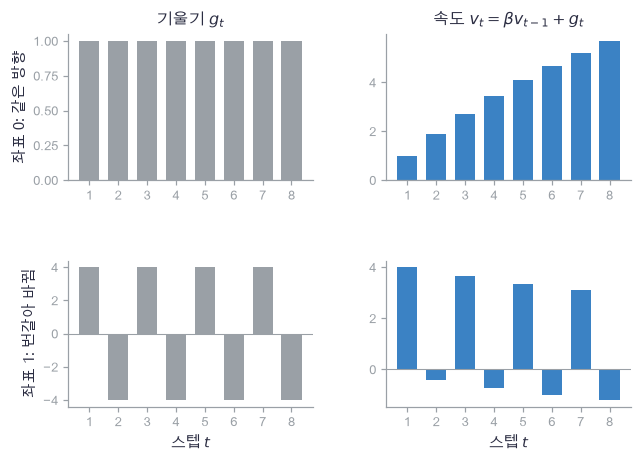

In [18]:
plot_state_bars(steps_8, [[g_steady, v_steady], [g_flip, v_flip]],
                ["기울기 $g_t$", "속도 $v_t = \\beta v_{t-1} + g_t$"], ["좌표 0: 같은 방향", "좌표 1: 번갈아 바뀜"])

🔍 **확인** · 위 행은 같은 방향의 기울기 1이 계속 들어와 속도가 $1+0.9+0.81+\cdots$로 쌓입니다(최대 $1/(1-\beta)=10$배).
아래 행은 3절의 튀는 세로 방향처럼 부호가 번갈아 바뀌어, 속도가 $4-3.6+\cdots$로 거의 상쇄됩니다.
그래서 Momentum은 완만한 방향은 빠르게, 튀는 방향은 조용하게 만듭니다. 대신 관성 때문에 최솟값을 지나쳤다가 돌아오기도 합니다.

In [19]:
def momentum_step(theta, gradient, state, learning_rate, beta=0.9):
    """Momentum 한 스텝: v ← βv + g, θ ← θ − ηv. 상태에 속도 v(θ와 같은 모양)를 기억합니다. → (새 θ, {"velocity", "t"})."""
    velocity = beta * state.get("velocity", np.zeros_like(theta)) + gradient   # 첫 스텝은 v_0 = 0
    updated = theta - learning_rate * velocity
    return updated, {"velocity": velocity, "t": state.get("t", 0) + 1}

In [20]:
# 쓰는 것: initial, g1, g2, sgd_first (3절 손계산 셀)
momentum_first, momentum_state = momentum_step(initial, g1, {}, 0.1)
momentum_second, momentum_state = momentum_step(momentum_first, g2, momentum_state, 0.1)
np.testing.assert_allclose(momentum_first, [0.8, -1.6])                    # 검산: v_1 = g_1이라 첫 스텝은 SGD와 같음
np.testing.assert_allclose(momentum_state["velocity"], [0.8, -1.6])        # 검산: v_2 = 0.9·(2, −4) + (−1, 2)
np.testing.assert_allclose(momentum_second, [0.72, -1.44])                 # 검산: (0.8, −1.6) − 0.1·(0.8, −1.6)
np.testing.assert_allclose(momentum_step(initial, g1, {}, 0.1, beta=0)[0], sgd_first)   # 검산: β = 0이면 SGD
print("Momentum 1회", momentum_first, "2회", momentum_second, "· v", momentum_state["velocity"])

Momentum 1회 [ 0.8 -1.6] 2회 [ 0.72 -1.44] · v [ 0.8 -1.6]


### ✏️ 연습 4 · 쌓이는 속도, 상쇄되는 속도

한 좌표에 기울기 `gradients` `(T,)`가 차례로 들어올 때, 스텝마다의 속도 $v_t=\beta v_{t-1}+g_t$를 담은 `velocities` `(T,)`를 채우는 반복문 안 두 줄을 쓰세요. 검사는 같은 방향이 이어질 때 쌓이는지, 부호가 번갈아 바뀔 때 상쇄되는지, 그리고 4절 그림 셀의 두 수열과 같은지 봅니다.

In [21]:
def exercise_velocity_sequence(gradients, beta):
    """연습 4: 한 좌표에 기울기가 T번 들어올 때의 속도 수열. gradients: (T,), beta: 숫자 → velocities: (T,)."""
    assert gradients.ndim == 1, "gradients는 한 좌표의 기울기 수열 (T,)이어야 합니다"
    velocities = np.zeros(len(gradients))          # (T,): 스텝마다의 v_t. 0으로 채워 두었으니 반복문이 모두 덮어써야 합니다
    velocity = 0.0                                 # v_0 = 0
    for t, g in enumerate(gradients):
        ### 이 주석 아래에 다음을 구현하세요.
        ### 구현할 내용: 이전 속도를 β배로 남기고 새 기울기 g를 더한 velocity, 그리고 그것을 velocities[t]에 기록
        ### 힌트: 4절 그림 셀에서 va를 갱신하는 줄과 같은 계산입니다. 수식 v_t = β v_{t−1} + g_t의 β가 인자 beta이고, 기록은 velocities[t]에 합니다.
        raise NotImplementedError
    return velocities

In [22]:
def check_velocity_sequence(candidate):
    """같은 방향 3번·번갈아 바뀌는 3번의 손계산과, 4절 그림 셀의 8스텝 수열 두 개로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: g_steady, g_flip, v_steady, v_flip, beta_m (4절 그림 셀)
    steady = candidate(np.ones(3), 0.9)
    assert steady.shape == (3,), f"속도 수열은 (T,) = (3,)이어야 하는데 {steady.shape}입니다"
    np.testing.assert_allclose(steady, [1., 1.9, 2.71])                                 # 검산: 1, 0.9·1 + 1, 0.9·1.9 + 1 → 쌓임
    np.testing.assert_allclose(candidate(np.array([4., -4., 4.]), 0.9), [4., -0.4, 3.64])   # 검산: 4, 0.9·4 − 4, 0.9·(−0.4) + 4 → 상쇄
    np.testing.assert_allclose(candidate(np.ones(3), 0.0), [1., 1., 1.])                 # 검산: β = 0이면 기억이 없어 v = g (SGD)
    np.testing.assert_allclose(candidate(g_steady, beta_m), v_steady)                    # 검산: 4절 그림의 위 행 (같은 방향)
    np.testing.assert_allclose(candidate(g_flip, beta_m), v_flip)                        # 검산: 4절 그림의 아래 행 (번갈아 바뀜)
    print("속도 수열: 손계산과 4절 그림의 수열에 일치합니다.")

run_check(check_velocity_sequence, exercise_velocity_sequence, hint="velocity = beta * velocity + g, velocities[t] = velocity")

☐ exercise_velocity_sequence: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: velocity = beta * velocity + g, velocities[t] = velocity


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
velocity = beta * velocity + g
velocities[t] = velocity
```

</details>

## 🔑 5. RMSProp: 좌표별 기울기 크기를 기억합니다

**이 절에서 가져갈 것:** 좌표마다 기울기 제곱의 이동 평균 $s$를 기억하고, 기울기를 $\sqrt s$로 나눕니다. 큰 기울기가 계속 나오는 좌표는 보폭이 작아지고, 작은 좌표는 커집니다.

> **용어**
>
> - **이동 평균(moving average)**: 옛 값을 $\rho$배로 잊고 새 값을 $(1-\rho)$배로 더하는 평균. 최근 값에 더 무게를 둡니다.
> - **2차 원시 모멘트**: 값의 제곱의 평균. 평균의 제곱을 빼지 않았으므로 분산과 구분합니다.
> - $\epsilon$: 0으로 나누는 것을 막는 작은 양수.

$$s_t=\rho s_{t-1}+(1-\rho)g_t^2,\qquad
\theta_t=\theta_{t-1}-\eta\frac{g_t}{\sqrt{s_t}+\epsilon}.$$

제곱과 나눗셈은 **원소별**입니다. `s.shape == theta.shape`이며, 크기가 큰 기울기가 계속 나온 좌표는 큰 분모를 갖습니다.
📎 구현 변형 중 여기서는 $\epsilon$을 제곱근 **밖**에 더합니다.

$\rho=0.9$와 $g_1=(2,-4)$라면 $s_1=(0.4,1.6)$입니다. 다음 $g_2=(-1,2)$에서는 $s_2=0.9(0.4,1.6)+0.1(1,4)=(0.46,1.84)$입니다.
아래는 한 좌표에는 작은 기울기 0.1이, 다른 좌표에는 큰 기울기 4가 계속 들어올 때입니다.

> **코드** · `np.full(8, 0.1)`: 0.1로 채운 길이 8의 배열. `g / np.sqrt(s)`는 원소별 나눗셈이라 스텝마다 그때의 s로 나눕니다.

In [23]:
rho_r = 0.9
g_small_c = np.full(8, 0.1)                              # 좌표 0: 작은 기울기
g_big_c = np.full(8, 4.0)                                # 좌표 1: 큰 기울기
s_small, s_big = [], []                                  # 스텝마다의 제곱 이동 평균 s_t
sa = sb = 0.0                                            # s_0 = 0
for ga, gb in zip(g_small_c, g_big_c):
    sa = rho_r * sa + (1 - rho_r) * ga ** 2              # s_t = ρ s_{t−1} + (1 − ρ) g_t²
    sb = rho_r * sb + (1 - rho_r) * gb ** 2
    s_small.append(sa)
    s_big.append(sb)
scaled_small = g_small_c / np.sqrt(s_small)              # (8,): 실제 보폭 방향 g/√s
scaled_big = g_big_c / np.sqrt(s_big)
np.testing.assert_allclose(scaled_small, scaled_big)     # 검산: 크기가 40배 달라도 나눈 뒤에는 같은 보폭
print("g/√s :", np.round(scaled_big, 2))

g/√s : [3.16 2.29 1.92 1.71 1.56 1.46 1.38 1.33]


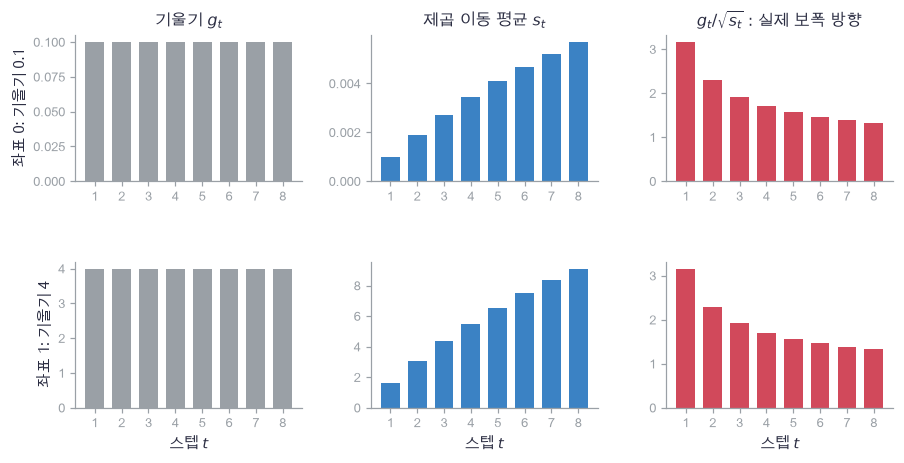

In [24]:
plot_state_bars(steps_8, [[g_small_c, s_small, scaled_small], [g_big_c, s_big, scaled_big]],
                ["기울기 $g_t$", "제곱 이동 평균 $s_t$", "$g_t / \\sqrt{s_t}$ : 실제 보폭 방향"], ["좌표 0: 기울기 0.1", "좌표 1: 기울기 4"])

🔍 **확인** · 기울기가 40배 다른 두 좌표가 $\sqrt s$로 나눈 뒤에는 같은 크기가 됩니다. 곡률이 큰 방향의 큰 기울기는 작게, 완만한 방향의 작은 기울기는 크게 만드는 셈입니다.
초반 값이 1보다 큰 이유는 $s$가 0에서 시작해 아직 $g^2$에 못 미치기 때문입니다. Adam은 이 초반 편향을 보정합니다.

In [25]:
def rmsprop_step(theta, gradient, state, learning_rate, rho=0.9, epsilon=1e-8):
    """RMSProp 한 스텝: s ← ρs + (1−ρ)g², θ ← θ − η g/(√s + ε). 상태에 제곱 이동 평균 s를 기억합니다. → (새 θ, {"square", "t"})."""
    square = rho * state.get("square", np.zeros_like(theta)) + (1-rho) * gradient**2   # (θ 모양): 좌표별
    updated = theta - learning_rate * gradient / (np.sqrt(square) + epsilon)         # ε은 제곱근 밖
    return updated, {"square": square, "t": state.get("t", 0) + 1}

In [26]:
# 쓰는 것: initial, g1, g2 (3절 손계산 셀)
# 이 손계산에서는 두 좌표의 분모가 양수이므로 epsilon=0으로 비교합니다.
rms_first, rms_state = rmsprop_step(initial, g1, {}, 0.1, epsilon=0)
np.testing.assert_allclose(rms_state["square"], [0.4, 1.6])                  # 검산: s_1 = 0.1·g_1² = (0.4, 1.6)
np.testing.assert_allclose(rms_first, [0.683772233983162, -1.683772233983162])   # 검산: (1, −2) − 0.1·(2, −4)/√(0.4, 1.6)
rms_second, rms_state = rmsprop_step(rms_first, g2, rms_state, 0.1, epsilon=0)
np.testing.assert_allclose(rms_state["square"], [0.46, 1.84])                # 검산: 0.9·(0.4, 1.6) + 0.1·(1, 4)
zero_result, _ = rmsprop_step(initial, np.zeros(2), {}, 0.1)  # 실제 기본값은 양의 epsilon
np.testing.assert_array_equal(zero_result, initial)           # 검산: 기울기 0이면 ε 덕분에 0/0 없이 제자리
print("RMSProp 1회", rms_first, "2회", rms_second, "· s", rms_state["square"])

RMSProp 1회 [ 0.683772 -1.683772] 2회 [ 0.831214 -1.831214] · s [0.46 1.84]


### ✏️ 연습 5 · 좌표별로 나누는 보폭

이전 상태를 꺼내는 줄과 반환은 미리 써 두었습니다. 기울기 제곱의 이동 평균 `square`와, 기울기를 `np.sqrt(square) + epsilon`으로 나눠 학습률만큼 옮긴 `updated` 두 줄을 채우세요. 검사는 $\rho=0.75$ 손계산에 더해, 기울기가 0.1과 4로 40배 다른 두 좌표가 나눈 뒤에는 같은 보폭으로 움직이는지, 그리고 $\epsilon$을 제곱근 밖에 더했는지도 봅니다.

In [27]:
def exercise_rmsprop_step(theta, gradient, state, learning_rate, rho=0.9, epsilon=1e-8):
    """연습 5: RMSProp 한 스텝. theta, gradient: 같은 모양, state: 사전 → (새 θ, {"square", "t"})."""
    previous_square = state.get("square", np.zeros_like(theta))     # 첫 스텝은 s_0 = 0
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: 제곱 이동 평균 square = ρ·이전 s + (1 − ρ)·g², 그리고 기울기를 √square + ε으로 나눠 학습률만큼 옮긴 updated
    ### 힌트: 5절 rmsprop_step의 두 줄입니다. 제곱·제곱근·나눗셈은 모두 원소별이고, ε은 제곱근 밖에 더합니다. 수식의 ρ가 인자 rho입니다.
    raise NotImplementedError
    return updated, {"square": square, "t": state.get("t", 0) + 1}

In [28]:
def check_rmsprop_step(candidate):
    """ρ = 0.75 손계산 하나, 크기가 40배 다른 두 좌표, 5절 손계산의 두 스텝, 기울기 0, ε의 자리로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: initial, g1, g2 (3절 손계산 셀) · rms_second (5절 손계산 셀)
    first, state = candidate(np.array([1., -2.]), np.array([2., -4.]), {}, 0.1, rho=0.75, epsilon=0)
    np.testing.assert_allclose(state["square"], [1., 4.])                 # 검산: s_1 = 0.25·(4, 16)
    np.testing.assert_allclose(first, [0.8, -1.8])                         # 검산: (1, −2) − 0.1·(2, −4)/√(1, 4) = (1, −2) − 0.1·(2, −2)
    same_stride, _ = candidate(np.zeros(2), np.array([0.1, 4.]), {}, 0.1, rho=0.75, epsilon=0)
    np.testing.assert_allclose(same_stride, [-0.2, -0.2])                  # 검산: g/√s = g/(0.5·|g|) = 2라서 40배 다른 기울기도 같은 보폭
    replay_first, replay_state = candidate(initial, g1, {}, 0.1, epsilon=0)
    replay_second, replay_state = candidate(replay_first, g2, replay_state, 0.1, epsilon=0)
    np.testing.assert_allclose(replay_state["square"], [0.46, 1.84])       # 검산: 5절 손계산 s_2 = 0.9·(0.4, 1.6) + 0.1·(1, 4)
    np.testing.assert_allclose(replay_second, rms_second)                  # 검산: 5절 rmsprop_step의 두 번째 결과와 같음
    zero_result, _ = candidate(np.zeros(2), np.zeros(2), {}, 0.1)
    np.testing.assert_array_equal(zero_result, np.zeros(2))                # 검산: 기울기 0이면 ε 덕분에 0/0 없이 제자리
    eps_outside, _ = candidate(np.zeros(1), np.array([0.1]), {}, 0.1, rho=0.0, epsilon=0.1)
    np.testing.assert_allclose(eps_outside, [-0.05])                       # 검산: ρ = 0이면 √s = |g| = 0.1. ε을 제곱근 밖에 더하면 0.1·0.1/(0.1 + 0.1) = 0.05 (안에 더하면 0.0302)
    print("RMSProp 한 스텝: 손계산과 일치합니다.")

run_check(check_rmsprop_step, exercise_rmsprop_step, hint="square = rho * previous_square + (1 - rho) * gradient ** 2, updated = theta - learning_rate * gradient / (np.sqrt(square) + epsilon)")

☐ exercise_rmsprop_step: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: square = rho * previous_square + (1 - rho) * gradient ** 2, updated = theta - learning_rate * gradient / (np.sqrt(square) + epsilon)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
square = rho * previous_square + (1 - rho) * gradient ** 2
updated = theta - learning_rate * gradient / (np.sqrt(square) + epsilon)
```

</details>

## 🔑 6. Adam: 1·2차 모멘트를 함께 쓰고 초기 편향을 보정합니다

**이 절에서 가져갈 것:** Adam은 Momentum의 방향 기억($m$)과 RMSProp의 크기 기억($s$)을 합치고, 0에서 시작해 작아진 초반 값을 $1/(1-\beta^t)$로 키워 보정합니다.

> **용어**
>
> - **편향 보정(bias correction)**: 이동 평균이 0에서 시작해 초반에 참값보다 작은 것을 $1-\beta^t$로 나누어 바로잡는 것. 학습 데이터의 편향과는 무관합니다.
> - $t$: 1부터 세는 **업데이트 횟수**. 에폭 수가 아니며 모멘트와 함께 상태로 유지합니다.

$$m_t=\beta_1m_{t-1}+(1-\beta_1)g_t,\qquad
s_t=\beta_2s_{t-1}+(1-\beta_2)g_t^2.$$

기울기가 항상 $g$라면 $m_t=(1-\beta_1)(1+\beta_1+\cdots+\beta_1^{t-1})g=(1-\beta_1^t)g$입니다. 이 계수로 나누어 초기값 0 때문에 생긴 편향을 보정합니다.

$$\hat m_t=\frac{m_t}{1-\beta_1^t},\quad\hat s_t=\frac{s_t}{1-\beta_2^t},\quad
\theta_t=\theta_{t-1}-\eta\frac{\hat m_t}{\sqrt{\hat s_t}+\epsilon}.$$

📎 아래 코드는 [Adam 원 논문의 Algorithm 1](https://arxiv.org/pdf/1412.6980)의 보정 후 분모 정의를 사용합니다. 아래는 기울기가 계속 2일 때 보정 전후의 모멘트입니다.

> **코드**
>
> - `beta1_a ** steps_20`: 스칼라를 배열 `(20,)`로 거듭제곱하면 β¹, β², …, β²⁰이 한 번에 나옵니다.
> - `[*state1["mean"], *state1["square"], *a1]`: 별표로 배열 세 개의 원소를 꺼내 목록 하나로 이어 붙입니다. 검산 한 줄로 셋을 비교하려는 것입니다.

In [29]:
steps_20 = np.arange(1, 21)                              # (20,): 스텝 번호 t = 1…20
beta1_a, beta2_a, g_const = 0.9, 0.999, 2.0             # 기울기가 계속 2인 경우
m_raw, s_raw = [], []                                   # 보정 전 m_t, s_t
m = s = 0.0                                             # m_0 = s_0 = 0
for _ in steps_20:
    m = beta1_a * m + (1 - beta1_a) * g_const           # m_t = β1 m_{t−1} + (1 − β1) g
    s = beta2_a * s + (1 - beta2_a) * g_const ** 2      # s_t = β2 s_{t−1} + (1 − β2) g²
    m_raw.append(m)
    s_raw.append(s)
m_hat = np.array(m_raw) / (1 - beta1_a ** steps_20)     # (20,): 보정 m̂_t = m_t/(1 − β1^t)
s_hat = np.array(s_raw) / (1 - beta2_a ** steps_20)     # (20,): 보정 ŝ_t
np.testing.assert_allclose(m_hat, g_const)              # 검산: 보정하면 첫 스텝부터 참값 g
np.testing.assert_allclose(s_hat, g_const ** 2)         # 검산: 보정하면 참값 g²
print("보정 전 m:", np.round(m_raw[:5], 3), "… · 보정 전 s:", np.round(s_raw[:5], 4), "…")

보정 전 m: [0.2   0.38  0.542 0.688 0.819] … · 보정 전 s: [0.004 0.008 0.012 0.016 0.02 ] …


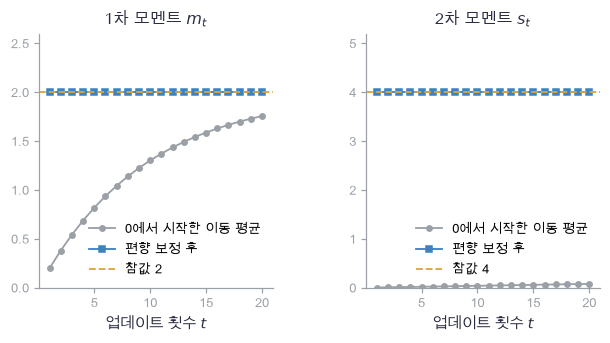

In [30]:
plot_bias_correction(steps_20, m_raw, m_hat, s_raw, s_hat, [g_const, g_const ** 2])

🔍 **확인** · 보정 전 $m_t$는 0.2에서 출발해 2에 천천히 다가가고, $s_t$는 $\beta_2=0.999$라 20스텝이 지나도 4에 한참 못 미칩니다. 보정하면 첫 스텝부터 참값 2와 4입니다.
보정이 없으면 초반에 $\hat m/\sqrt{\hat s}$의 크기가 왜곡됩니다. 실제 학습에서는 기울기가 바뀌므로 곡선이 이처럼 일정하지 않습니다.

In [31]:
def adam_step(theta, gradient, state, learning_rate, beta1=0.9, beta2=0.999, epsilon=1e-8):
    """Adam 한 스텝: m ← β1 m + (1−β1)g, s ← β2 s + (1−β2)g², m̂ = m/(1−β1^t), ŝ = s/(1−β2^t), θ ← θ − η m̂/(√ŝ + ε).
    상태에 m, s (θ 모양)와 스텝 수 t를 기억합니다. → (새 θ, {"mean", "square", "t"})."""
    t = state.get("t", 0) + 1                                                          # 1부터 세는 업데이트 횟수
    mean = beta1 * state.get("mean", np.zeros_like(theta)) + (1-beta1) * gradient      # 1차 모멘트 (방향)
    square = beta2 * state.get("square", np.zeros_like(theta)) + (1-beta2) * gradient**2   # 2차 원시 모멘트 (크기)
    corrected_mean = mean / (1-beta1**t)                                               # 편향 보정
    corrected_square = square / (1-beta2**t)
    updated = theta - learning_rate * corrected_mean / (np.sqrt(corrected_square) + epsilon)   # 좌표별 보폭
    return updated, {"mean": mean, "square": square, "t": t}

In [32]:
# 쓰는 것: initial (3절 손계산 셀)
# 손계산을 쉽게 하려고 두 beta를 0.5로 놓고, 양수 분모에서 epsilon=0으로 비교합니다.
a0 = np.array([1.])
a1, state1 = adam_step(a0, np.array([2.]), {}, 0.1, beta1=0.5, beta2=0.5, epsilon=0)
a2, state2 = adam_step(a1, np.array([-2.]), state1, 0.1, beta1=0.5, beta2=0.5, epsilon=0)
# t=1: m=1, s=2, 보정 후 m=2, s=4 → 0.1만큼 감소
np.testing.assert_allclose([*state1["mean"], *state1["square"], *a1], [1., 2., 0.9])          # 검산: 위 손계산
# t=2: m=-0.5, s=3, 보정 후 m=-2/3, s=4 → 1/30만큼 증가
np.testing.assert_allclose([*state2["mean"], *state2["square"], *a2], [-0.5, 3., 14/15])      # 검산: 위 손계산
assert state2["t"] == 2, "두 번 갱신했으므로 t = 2여야 합니다"
np.testing.assert_allclose(adam_step(initial, np.zeros(2), {}, 0.1)[0], initial)             # 검산: 기울기 0이면 제자리
print("Adam 1회", a1, "2회", a2, "· 2회 상태", state2)

Adam 1회 [0.9] 2회 [0.933333] · 2회 상태 {'mean': array([-0.5]), 'square': array([3.]), 't': 2}


In [33]:
# 쓰는 것: g_const, m_raw, s_raw, steps_20 (6절 보정 그림 셀)
constant_theta, constant_state = np.array([0.]), {}
raw_mean, raw_square = [], []                                            # adam_step이 기억한 m, s
for t in steps_20:
    constant_theta, constant_state = adam_step(constant_theta, np.array([g_const]), constant_state, 0.1)   # 기울기 2를 20번
    raw_mean.append(constant_state["mean"][0])
    raw_square.append(constant_state["square"][0])
np.testing.assert_allclose(raw_mean, m_raw)          # 검산: 위 그림의 재귀식과 같은 m
np.testing.assert_allclose(raw_square, s_raw)        # 검산: 같은 s
print("adam_step의 상태가 손으로 쓴 재귀식과 일치합니다. 20스텝 뒤 θ =", constant_theta)

adam_step의 상태가 손으로 쓴 재귀식과 일치합니다. 20스텝 뒤 θ = [-2.]


🔍 **확인** · SGD·Momentum·RMSProp·Adam의 차이를 이름 대신 **어떤 배열을 다음 스텝까지 기억하는가**로 정리할 수 있습니다.

| 방법 | 유지할 상태 | 이번 갱신에 사용한 방향 |
|---|---|---|
| SGD | 계산에 필요한 누적 상태 없음 | 현재 g |
| Momentum | 이전 기울기의 가중합 v | v |
| RMSProp | 제곱 이동 평균 s | g를 좌표별 크기로 나눈 값 |
| Adam | 이동 평균 m·s, 스텝 t | 보정한 m을 보정한 제곱 크기로 나눈 값 |

### ✏️ 연습 6 · 방향과 크기를 함께 기억하기

편향 보정 두 줄과 갱신 줄은 미리 써 두었습니다(노트북 끝의 연습 B가 그 반대입니다). Momentum처럼 방향을 기억하는 `mean`과 RMSProp처럼 크기를 기억하는 `square` 두 줄을 채우세요. 검사는 $\beta_1=\beta_2=0.5$ 손계산과 두 $\beta$가 다른 경우에 더해, 기울기 2가 20번 들어올 때 보정 전 $m$·$s$가 6절 그림 셀의 재귀식과 같은지 봅니다.

In [34]:
def exercise_adam_moments(theta, gradient, state, learning_rate, beta1=0.9, beta2=0.999, epsilon=1e-8):
    """연습 6: Adam 한 스텝. 편향 보정과 갱신 줄은 미리 있고, 두 이동 평균 m·s를 채웁니다. → (새 θ, {"mean", "square", "t"})."""
    t = state.get("t", 0) + 1                                                          # 1부터 세는 업데이트 횟수
    previous_mean = state.get("mean", np.zeros_like(theta))                            # 첫 스텝은 m_0 = 0
    previous_square = state.get("square", np.zeros_like(theta))                        # s_0 = 0
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: Momentum처럼 방향을 기억하는 mean = β1·이전 m + (1 − β1)·g, RMSProp처럼 크기를 기억하는 square = β2·이전 s + (1 − β2)·g²
    ### 힌트: 6절 adam_step의 두 이동 평균 줄입니다. 4절 Momentum과 달리 새 기울기에 (1 − β1)을 곱합니다. 수식의 β1, β2가 인자 beta1, beta2입니다.
    raise NotImplementedError
    corrected_mean = mean / (1 - beta1 ** t)                                           # 편향 보정
    corrected_square = square / (1 - beta2 ** t)
    updated = theta - learning_rate * corrected_mean / (np.sqrt(corrected_square) + epsilon)
    return updated, {"mean": mean, "square": square, "t": t}

In [35]:
def check_adam_moments(candidate):
    """β = 0.5 손계산 두 스텝, 두 β가 다른 경우, 기울기가 계속 2일 때 6절 그림 셀의 보정 전 m·s로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: g_const, m_raw, s_raw, steps_20 (6절 보정 그림 셀)
    first, state = candidate(np.array([1.]), np.array([2.]), {}, 0.1, beta1=0.5, beta2=0.5, epsilon=0)
    np.testing.assert_allclose([*state["mean"], *state["square"], *first], [1., 2., 0.9])   # 검산: m_1 = 0.5·2, s_1 = 0.5·4, 보정 뒤 2와 4 → 1 − 0.1·2/2
    second, state = candidate(first, np.array([-2.]), state, 0.1, beta1=0.5, beta2=0.5, epsilon=0)
    np.testing.assert_allclose([*state["mean"], *state["square"]], [-0.5, 3.])             # 검산: m_2 = 0.5·1 + 0.5·(−2), s_2 = 0.5·2 + 0.5·4
    _, mixed_state = candidate(np.array([1.]), np.array([2.]), {}, 0.1, beta1=0.5, beta2=0.75, epsilon=0)
    np.testing.assert_allclose([*mixed_state["mean"], *mixed_state["square"]], [1., 1.])   # 검산: m은 β1 = 0.5로 0.5·2, s는 β2 = 0.75로 0.25·4
    replay_theta, replay_state = np.array([0.]), {}
    for _ in steps_20:
        replay_theta, replay_state = candidate(replay_theta, np.array([g_const]), replay_state, 0.1)   # 기울기 2를 20번
    np.testing.assert_allclose(replay_state["mean"], m_raw[-1])                             # 검산: 20스텝 뒤 보정 전 m = 6절 그림 셀의 재귀식
    np.testing.assert_allclose(replay_state["square"], s_raw[-1])                           # 검산: 보정 전 s도 같음
    print("Adam의 두 이동 평균: 손계산과 6절 그림의 수열에 일치합니다.")

run_check(check_adam_moments, exercise_adam_moments, hint="mean = beta1 * previous_mean + (1 - beta1) * gradient, square = beta2 * previous_square + (1 - beta2) * gradient ** 2")

☐ exercise_adam_moments: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: mean = beta1 * previous_mean + (1 - beta1) * gradient, square = beta2 * previous_square + (1 - beta2) * gradient ** 2


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
mean = beta1 * previous_mean + (1 - beta1) * gradient
square = beta2 * previous_square + (1 - beta2) * gradient ** 2
```

</details>

## 🔍 7. 같은 이차 목적에서 경로를 비교합니다

1절의 목적·초기값을 고정하고 120회 갱신합니다.
비교에는 각 방법의 학습률도 함께 표시합니다. 같은 숫자의 학습률이 서로 같은 변화량을 뜻하지 않으므로,
이 한 설정을 optimizer의 보편적인 순위로 해석하지 않습니다.
`history['theta'][t]`와 `history['loss'][t]`는 같은 시점의 파라미터와 목적값입니다.

> **코드**
>
> - `for name, (step_function, rate) in optimizer_specs.items()`: 사전의 값이 (함수, 학습률) 쌍이라 괄호로 한 번 더 풀어 받습니다. 함수도 값처럼 사전에 넣고 꺼내 부를 수 있습니다.
> - `{key: np.array(value) for key, value in history.items()}`: 기록 목록들을 배열로 바꾸는 사전 컴프리헨션(01b 4절).

In [36]:
def run_quadratic(step_function, learning_rate, steps=120):
    """이차 목적에서 optimizer 하나를 steps번 돌립니다. step_function: 3–6절의 갱신 함수 → {"theta": (steps+1, 2), "loss": (steps+1,)}."""
    # 쓰는 것: theta_start (1·3절) · quadratic (1절)
    theta = theta_start.copy()                              # 시작점을 복사해 원본 보존
    state = {}                                              # 빈 상태로 시작
    history = {"theta": [theta.copy()], "loss": [quadratic(theta)[0]]}   # 시작점부터 기록
    for t in range(steps):
        _, gradient = quadratic(theta)                      # 기울기만
        theta, state = step_function(theta, gradient, state, learning_rate)   # 갱신 규칙만 다름
        history["theta"].append(theta.copy())
        history["loss"].append(quadratic(theta)[0])
    return {key: np.array(value) for key, value in history.items()}

In [37]:
# 쓰는 것: sgd_step, momentum_step, rmsprop_step, adam_step (3–6절)
optimizer_specs = {                                          # 이름 → (갱신 함수, 학습률)
    "SGD η=0.08": (sgd_step, 0.08),
    "Momentum η=0.03": (momentum_step, 0.03),
    "RMSProp η=0.08": (rmsprop_step, 0.08),
    "Adam η=0.08": (adam_step, 0.08),
}
quadratic_histories = {}
for name, (step_function, rate) in optimizer_specs.items():
    history = run_quadratic(step_function, rate)
    assert np.all(np.isfinite(history["loss"])), f"{name}: 목적값이 발산하면 안 됩니다"
    assert history["loss"][-1] < history["loss"][0], f"{name}: 120스텝 뒤 목적값이 처음보다 작아야 합니다"
    quadratic_histories[name] = history
    print(name, "· 마지막 목적값", history["loss"][-1])
# xx·yy·surface.shape=(100,100). 학습 계산은 위 루프에서 수행했습니다.
xx, yy = np.meshgrid(np.linspace(-1.2, 3.4, 100), np.linspace(-1.3, 1.3, 100))   # 그림용 격자 (3절과 범위가 다름)
surface = 0.5 * (xx**2 + 20 * yy**2)

SGD η=0.08 · 마지막 목적값 9.168347733964372e-09
Momentum η=0.03 · 마지막 목적값 1.5808498185671706e-05
RMSProp η=0.08 · 마지막 목적값 0.036501099256119836
Adam η=0.08 · 마지막 목적값 6.339187231575337e-05


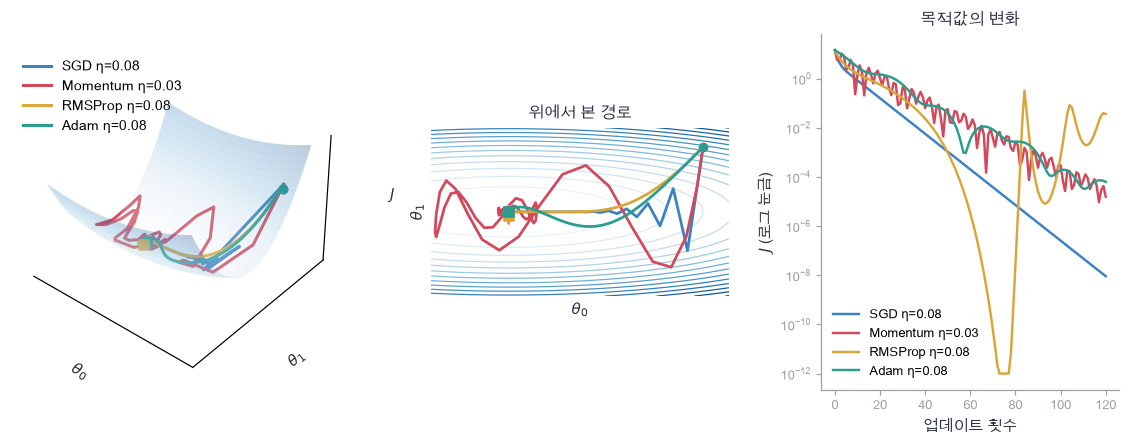

In [38]:
plot_optimizer_landscape(xx, yy, surface, quadratic_histories)

🔍 **확인** · 3절의 지그재그와 비교해 보세요. Momentum은 세로 진동을 상쇄해 곧게 가고, RMSProp·Adam은 세로와 가로의 보폭을 맞춰 대각선으로 갑니다.
모멘텀의 누적과 적응형 분모 때문에 같은 목적에서도 경로가 달라집니다.
최솟값 가까이에서 진동하거나 잠시 손실이 커지는 것도 볼 수 있습니다. 각 스텝이 반드시 손실을 줄이는 방법들이라는 뜻은 아닙니다.

## 🔍 8. 실제 회귀: 같은 초기값과 배치 순서로 비교합니다

붉기에서 당도 $y=1.7x-0.4+\text{잡음}$을 맞히는 데이터를 만들고 네 방법으로 학습합니다.
배치 크기는 16, 표본은 65개이므로 마지막 배치는 1개입니다. 이 작은 배치도 실제 크기로 평균냅니다.
모든 방법에 **같은 미리 만든 인덱스 순서**, 같은 초기값을 전달합니다.
기록할 손실은 매 스텝 전체 학습셋에서 계산하며, 업데이트 기울기는 현재 배치에서 계산합니다.

📎 `seen`은 처리한 표본 수입니다. 서로 다른 배치 크기를 나중에 비교할 때는 스텝 수와 처리한 표본 수를 함께 살펴야 합니다.

> **코드**
>
> - `batch_schedule.extend(epoch_batches(…))`: 에폭마다 만든 배치 목록을 하나의 긴 목록 뒤에 이어 붙입니다. 40에폭 × 5배치 = 200개.
> - `sum(map(len, batch_schedule))`: 배치마다 길이를 재서(`map`) 모두 더한 것. 처리한 표본 수 65 × 40이어야 합니다.
> - `np.linalg.lstsq(F, y, rcond=None)[0]`: 최소제곱 해(01번 7절). 돌려주는 네 값 중 첫 번째만 씁니다.

In [39]:
def train_regression(features, targets, initial_theta, schedule, step_function, learning_rate):
    """미리 만든 배치 순서 schedule대로 미니배치 학습. 스텝마다 배치 기울기로 갱신하고, 기록은 전체 데이터 손실로 합니다.
    features: (N, 2), targets: (N,), initial_theta: (2,), schedule: 배치 인덱스 목록 → (θ, 마지막 상태, history{"loss", "gradient_norm", "seen"})."""
    # 쓰는 것: regression_loss_gradient (2절)
    theta = initial_theta.copy()                            # 시작값을 복사해 실험끼리 공유하지 않음
    state = {}
    history = {"loss": [], "gradient_norm": [], "seen": []}
    seen = 0                                                # 처리한 표본 수
    for step in range(len(schedule) + 1):                   # 마지막 바퀴는 기록만
        full_loss, full_gradient = regression_loss_gradient(features, targets, theta)   # 전체 데이터 (기록용, 갱신에는 안 씀)
        history["loss"].append(full_loss)
        history["gradient_norm"].append(np.linalg.norm(full_gradient))   # 전체 기울기의 크기 ‖g‖
        history["seen"].append(seen)
        if step == len(schedule):
            break
        batch = schedule[step]                              # 이번 스텝의 배치 인덱스 (B,)
        _, gradient = regression_loss_gradient(features[batch], targets[batch], theta)   # 배치만의 기울기
        theta, state = step_function(theta, gradient, state, learning_rate)
        seen += len(batch)                                  # 마지막 배치는 더 작을 수 있음
    return theta, state, {key: np.array(value) for key, value in history.items()}

In [40]:
# 쓰는 것: epoch_batches, regression_loss_gradient (2절) · sgd_step, momentum_step, rmsprop_step, adam_step (3–6절)
# 1. 데이터: 붉기 65개와 당도 y = 1.7x − 0.4 + 잡음
rng_data = np.random.default_rng(41)
x_train = np.linspace(-2, 2, 65)                                                 # (65,)
features = np.column_stack([x_train, np.ones(len(x_train))])                     # (65, 2): [x, 1]
targets = 1.7*x_train - 0.4 + rng_data.normal(0, 0.12, len(x_train))             # (65,)
# 2. 배치 순서: 40에폭 × (16개씩 → 크기 [16, 16, 16, 16, 1])을 미리 만들어 네 방법에 똑같이 줌
rng_order = np.random.default_rng(42)
batch_schedule = []
for epoch in range(40):
    batch_schedule.extend(epoch_batches(len(x_train), 16, rng_order))
assert len(batch_schedule) == 200, "40에폭 × 5배치 = 200스텝이어야 합니다"
assert sum(map(len, batch_schedule)) == 65*40, "처리한 표본 수는 65 × 40이어야 합니다"
# 3. 같은 초기값에서 네 방법 학습
initial_theta = np.array([-1., 1.])                                              # (2,): [w, b] 시작값
regression_specs = {"SGD η=0.08": (sgd_step, 0.08), "Momentum η=0.03": (momentum_step, 0.03),
                    "RMSProp η=0.03": (rmsprop_step, 0.03), "Adam η=0.05": (adam_step, 0.05)}
regression_histories = {}
for name, (step_function, rate) in regression_specs.items():
    theta, state, history = train_regression(features, targets, initial_theta, batch_schedule,
                                              step_function, rate)
    assert state["t"] == len(batch_schedule), "스텝 수는 배치 수와 같아야 합니다"
    assert history["seen"][-1] == len(x_train) * 40, "처리한 표본 수는 65 × 40이어야 합니다"
    assert history["loss"][-1] < history["loss"][0] / 10, f"{name}: 손실이 처음의 1/10 아래로 내려가야 합니다"
    regression_histories[name] = history
    print(f"{name}: θ={theta}, loss={history['loss'][-1]:.6f}, steps={state['t']}")
# 4. 독립 기준: 같은 데이터의 최소제곱 해
least_squares = np.linalg.lstsq(features, targets, rcond=None)[0]                # (2,)
print("독립 최소제곱 해", least_squares, "· 최소 손실", regression_loss_gradient(features, targets, least_squares)[0])

SGD η=0.08: θ=[ 1.700046 -0.394376], loss=0.005942, steps=200


Momentum η=0.03: θ=[ 1.700313 -0.383934], loss=0.006081, steps=200
RMSProp η=0.03: θ=[ 1.701483 -0.345318], loss=0.007544, steps=200
Adam η=0.05: θ=[ 1.703473 -0.404286], loss=0.005918, steps=200
독립 최소제곱 해 [ 1.700257 -0.402473] · 최소 손실 0.005909222626615713


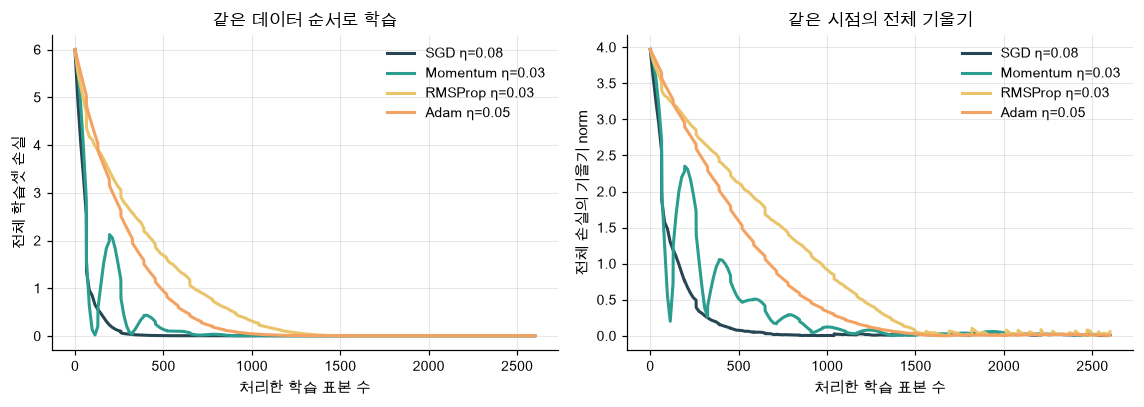

In [41]:
plot_regression_runs(regression_histories)

🔍 **확인** · 이 실험은 작은 선형 회귀이며 설정을 고르기 위한 대규모 성능 비교가 아닙니다.
해석할 때는 선택한 학습률, 동일한 200회 업데이트·2600개 표본 처리, 학습셋에서 측정한 손실을 함께 읽습니다.
최소제곱 해는 이 회귀 문제의 독립 기준이고, 정해진 횟수의 미니배치 업데이트가 그 해에 정확히 도달할 필요는 없습니다.

### 🔍 MNIST에서 가중치 이미지가 자라나는 속도

같은 `train_regression`을 MNIST 7 판별 회귀(`(5000, 785)`)에 씁니다. 배치 64장으로 1·10·100스텝 뒤의 가중치를 이미지로 봅니다.
초기값은 모두 0, 배치 순서는 세 방법에 같습니다. 학습률은 방법마다 다르게 골랐습니다.

In [42]:
# 쓰는 것: mnist_F, mnist_T (📎 데이터 셀) · epoch_batches (2절) · sgd_step, momentum_step, adam_step (3·4·6절) · train_regression (8절)
rng_mnist_order = np.random.default_rng(42)
mnist_schedule = []                                                  # 2에폭 × (5,000장을 64개씩 → 79배치)
for epoch in range(2):
    mnist_schedule.extend(epoch_batches(len(mnist_T), 64, rng_mnist_order))
mnist_specs = {"SGD η=0.05": (sgd_step, 0.05), "Momentum η=0.01": (momentum_step, 0.01), "Adam η=0.01": (adam_step, 0.01)}
snapshot_steps = [1, 10, 100]                                        # 가중치 이미지를 볼 스텝
mnist_images, mnist_losses = {}, {}                                  # 이름 → 스텝별 (28, 28) 이미지 / 전체 손실
for name, (step_function, rate) in mnist_specs.items():
    mnist_images[name], mnist_losses[name] = [], []
    for k in snapshot_steps:
        theta_k, _, history_k = train_regression(mnist_F, mnist_T, np.zeros(785), mnist_schedule[:k], step_function, rate)   # 앞 k배치만 써서 k스텝
        mnist_images[name].append(theta_k[:784].reshape(28, 28))    # 편향 자리(마지막 원소)를 뺀 784개를 이미지로
        mnist_losses[name].append(history_k["loss"][-1])
    print(name, "· 손실", np.round(mnist_losses[name], 4))

SGD η=0.05 · 손실 [0.058  0.0418 0.0275]


Momentum η=0.01 · 손실 [0.0492 0.0284 0.0202]
Adam η=0.01 · 손실 [0.3789 0.0497 0.0179]


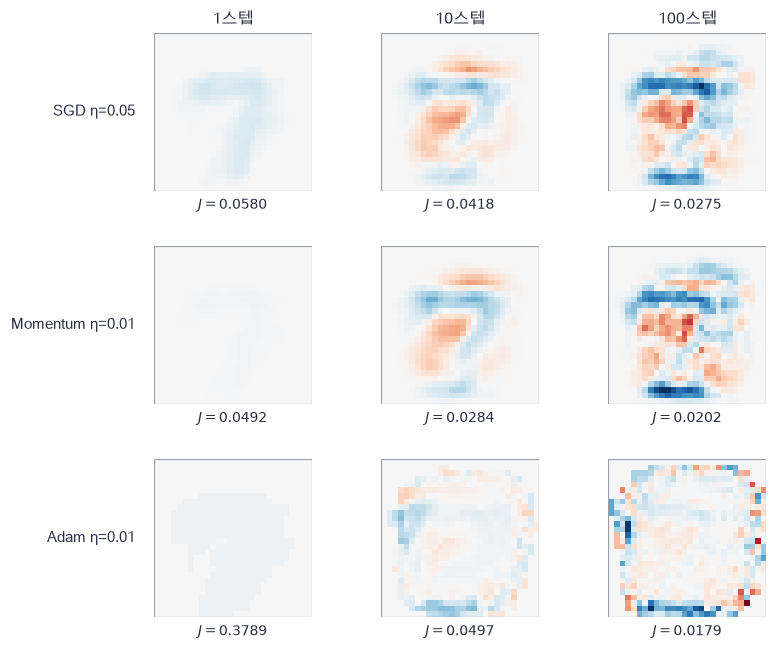

In [43]:
plot_optimizer_templates(mnist_images, mnist_losses, snapshot_steps)

🔍 **확인** · 행마다 색 눈금이 다릅니다(각 optimizer의 최대 크기 기준). 첫 스텝에서 SGD와 Momentum은 첫 배치의 기울기 이미지에 학습률을 곱한 것이라 모양이 같고 크기만 다릅니다.
10스텝 뒤 Momentum은 같은 방향의 기울기를 쌓아 SGD보다 진하고, 100스텝 뒤 손실도 더 낮습니다.
Adam은 화소마다 기울기 크기로 나누므로, 잉크가 거의 없어 기울기가 아주 작은 **가장자리 화소까지 같은 보폭으로** 움직입니다. 그래서 테두리가 진하게 칠해지고 첫 스텝 손실이 오히려 커졌다가 100스텝 뒤에는 가장 낮아집니다.
같은 데이터·같은 배치 순서에서 갱신 규칙만 바꿔도 가중치가 만들어지는 과정이 이렇게 다릅니다.

## 🔍 9. optimizer 앞뒤도 확인합니다: 초기화·기울기 크기·학습률

> **용어**
>
> - **초기화(initialization)**: 학습 시작 전 가중치에 넣는 난수의 분포. 크기를 잘못 잡으면 활성값과 기울기가 층을 지나며 커지거나 사라집니다.
> - **He 초기화**: ReLU 층에서 입력·출력의 제곱 크기를 비슷하게 유지하도록 표준편차를 $\sqrt{2/D}$로 잡는 것.

### 초기화의 크기는 forward와 backward 모두에 영향을 줍니다

03에서 서로 다른 초기값이 필요함을 보았습니다. 크기도 중요합니다.
가중치끼리 독립이고 평균이 0이며 같은 분산을 갖고, 가중치 벡터가 입력과 독립이라고 가정합니다.
각 입력 성분의 제곱 평균도 같다고 놓습니다. $z=\sum_{d=1}^{D}w_da_d$를 제곱해 기댓값을 취하면

$$\mathbb E[z^2]=\sum_i\mathbb E[w_i^2]\mathbb E[a_i^2]
+\sum_{i\ne j}\mathbb E[w_iw_j]\mathbb E[a_ia_j].$$

독립인 두 변수는 결합확률이 곱으로 나뉘므로
$\mathbb E[UV]=\sum_{u,v}uv\,p(u)p(v)=(\sum_u u\,p(u))(\sum_v v\,p(v))=\mathbb E[U]\mathbb E[V]$입니다.
연속 분포에서도 합을 적분으로 바꾸어 같은 관계를 얻습니다.

교차항에서는 $\mathbb E[w_iw_j]=\mathbb E[w_i]\mathbb E[w_j]=0$이므로 두 번째 합이 사라집니다.
또한 $\mathbb E[z]=0$, $\mathbb E[w_i^2]=\operatorname{Var}(w)$이므로
$\operatorname{Var}(z)=D\operatorname{Var}(w)\mathbb E[a^2]$가 됩니다.
같은 크기의 항 D개를 합한 결과가 코드에서 사용하는 `fan_in=D`와 연결됩니다.
분포가 0을 중심으로 대칭이면 ReLU가 제곱 크기의 절반을 남겨 $\mathbb E[\operatorname{ReLU}(z)^2]=\mathbb E[z^2]/2$입니다.
이 근사로 입력·출력의 제곱 크기를 비슷하게 유지하려면 $\operatorname{Var}(w)\approx2/D$, 표준편차는 $\sqrt{2/D}$를 택합니다. 이것이 여기서 쓰는 He 초기화입니다.

03의 tanh에는 Glorot 표준편차 $\sqrt{2/(d_{in}+d_{out})}$를 사용했습니다.
초기화의 전제는 실제 학습 중 모든 층에서 정확히 유지되지 않습니다. 아래 실험은 크기 변화가 어떻게 전달되는지 관찰하는 작은 진단입니다.
[He 외의 원 논문](https://arxiv.org/abs/1502.01852), [Glorot·Bengio의 원 논문](https://proceedings.mlr.press/v9/glorot10a.html).

먼저 D=2, 입력 `[1,1]`, 독립 가중치가 각각 -1 또는 1인 작은 경우를 전부 열거합니다.
네 결과가 같은 확률이면 z는 `[-2,0,0,2]`, 분산은 2이고 ReLU 출력 제곱의 평균은 1입니다.
그다음 입력은 `(256,32)`, 은닉층은 모두 너비 32인 6개 층으로 늘립니다.
forward의 활성값 제곱 평균과, 마지막 출력 합 $G=\sum A_6$에서 시작한 backward의 RMS를 계산합니다.
RMS(root mean square)는 `sqrt(mean(value**2))`입니다. G를 이렇게 정하면 마지막 상류 기울기는 모두 1입니다.
실제 분류 손실을 학습하는 대신, 동일한 상류 기울기가 각 층을 거치며 어떻게 변하는지 봅니다.

> **코드**
>
> - `[base * standard_deviation for base in base_weights]`: 같은 난수 행렬 6개에 표준편차만 곱해 크기 세 가지를 비교합니다.
> - `range(len(weights) - 1, -1, -1)`: 마지막 층부터 0까지 거꾸로. `[None] * n`은 n칸짜리 빈 목록입니다(03번 5절).
> - `dA * (Z > 0)`: True/False 배열을 곱하면 1/0을 곱한 것과 같습니다. ReLU의 도함수를 곱하는 backward입니다.

In [44]:
def inspect_initialization(X, base_weights, standard_deviation):
    """ReLU 층 여러 개를 지나며 forward의 활성값 제곱 평균과, 출력 합 G = ΣA_L에서 시작한 backward의 기울기 RMS를 잽니다.
    X: (N, D), base_weights: (D, D) 난수 행렬 목록, standard_deviation: 곱할 크기 → (제곱 평균 (L+1,), 기울기 RMS (L+1,))."""
    weights = [base * standard_deviation for base in base_weights]   # 크기만 바꾼 가중치들
    activations = [X]                                                # A_0 = X
    preactivations = []
    for W in weights:                                                # forward: Z = A W, A = ReLU(Z)
        Z = activations[-1] @ W
        preactivations.append(Z)
        activations.append(np.maximum(Z, 0))
    second_moments = [np.mean(A**2) for A in activations]           # 층마다 E[A²]
    dA = np.ones_like(activations[-1])                               # G = ΣA_L이므로 마지막 상류 기울기는 모두 1
    gradient_rms = [None] * len(activations)
    gradient_rms[-1] = np.sqrt(np.mean(dA**2))
    for layer_index in range(len(weights) - 1, -1, -1):             # backward: 마지막 층부터
        dZ = dA * (preactivations[layer_index] > 0)                  # ReLU 도함수를 곱함
        dA = dZ @ weights[layer_index].T                             # 앞 층 활성의 기울기
        gradient_rms[layer_index] = np.sqrt(np.mean(dA**2))          # RMS = √mean(dA²)
    return np.array(second_moments), np.array(gradient_rms)

In [45]:
weight_cases = np.array([[-1., -1.], [-1., 1.], [1., -1.], [1., 1.]])   # (4, 2): 가중치 두 개가 각각 ±1인 네 경우
z_cases = weight_cases @ np.ones(2)                                       # (4,): 입력 [1, 1]에서의 z = w0 + w1 = −2, 0, 0, 2
case_probabilities = np.full(4, 0.25)                                    # 네 경우가 같은 확률
mean_z = np.sum(case_probabilities * z_cases)                            # E[z] (02번 1절의 기댓값)
variance_z = np.sum(case_probabilities * (z_cases - mean_z)**2)          # Var(z)
relu_second_moment = np.sum(case_probabilities * np.maximum(z_cases, 0)**2)   # E[ReLU(z)²]
np.testing.assert_allclose([mean_z, variance_z, relu_second_moment], [0., 2., 1.])   # 검산: 0, D·Var(w)·E[a²] = 2·1·1, 그 절반
print("두 입력의 완전열거: Var(z)=", variance_z, "E[ReLU(z)^2]=", relu_second_moment)

두 입력의 완전열거: Var(z)= 2.0 E[ReLU(z)^2]= 1.0


In [46]:
rng_init = np.random.default_rng(43)
init_X = rng_init.normal(size=(256, 32))                                 # (256, 32): 입력. 제곱 평균 약 1
base_weights = [rng_init.normal(size=(32, 32)) for _ in range(6)]        # 층 6개의 표준 정규 난수 행렬
init_scales = {"작게": 0.1/np.sqrt(32), "He": np.sqrt(2/32), "크게": 3/np.sqrt(32)}   # 표준편차 세 가지. He = √(2/D)
second_moments, gradient_rms = {}, {}
for name, scale in init_scales.items():
    moments, rms = inspect_initialization(init_X, base_weights, scale)
    assert np.all(np.isfinite(moments)), f"{name}: 활성값이 넘치면 안 됩니다"
    assert np.all(np.isfinite(rms)), f"{name}: 기울기가 넘치면 안 됩니다"
    second_moments[name], gradient_rms[name] = moments, rms
    print(f"{name}: 마지막 활성값 제곱 평균 {moments[-1]:.3e}, 입력 기울기 RMS {rms[0]:.3e}")

작게: 마지막 활성값 제곱 평균 9.196e-15, 입력 기울기 RMS 2.121e-07
He: 마지막 활성값 제곱 평균 5.885e-01, 입력 기울기 RMS 1.697e+00
크게: 마지막 활성값 제곱 평균 4.887e+03, 입력 기울기 RMS 1.546e+02


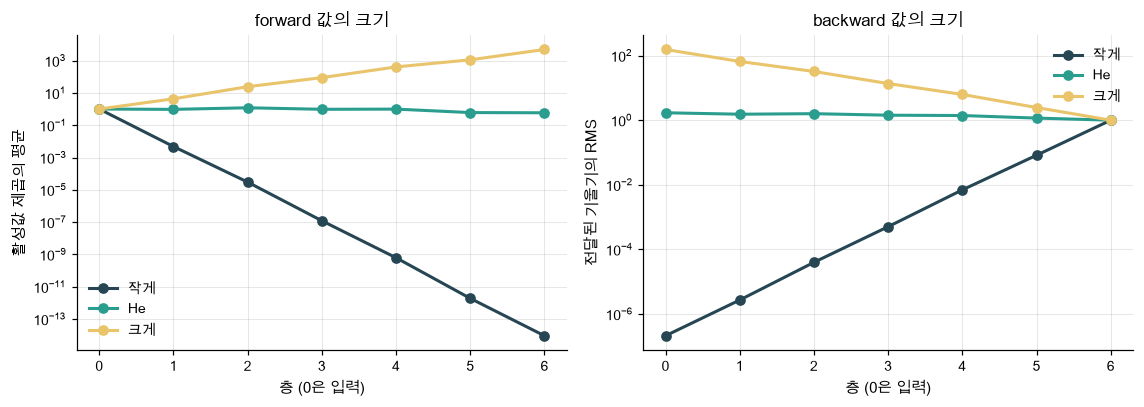

In [47]:
plot_initialization(np.arange(7), second_moments, gradient_rms)

🔍 **확인** · 큰 크기 차이는 optimizer를 고르기 전에 생겼습니다. 이 그림의 seed 한 개로 초기화 전체의 성능을 평가하지는 않습니다.
초기화 후 활성값·기울기가 계산 가능한 크기인지 살펴보고, 03처럼 실제 목적함수의 기울기도 검산합니다.

### 🔍 Gradient clipping과 학습률 스케줄

> **용어**
>
> - **gradient clipping**: 기울기 벡터의 크기(norm)가 정한 값 $c$를 넘으면 방향은 두고 크기만 $c$로 줄이는 것.
> - **학습률 스케줄**: 스텝 $t$에 따라 학습률을 미리 정한 규칙으로 바꾸는 것. 예: $\eta_t=\eta_0/(1+kt)$.

전체 기울기의 Euclidean norm $\|g\|_2=\sqrt{\sum_i g_i^2}$가 $c$보다 크면
$g\leftarrow g\,c/\|g\|_2$로 크기를 줄일 수 있습니다. 방향은 같지만 원래 손실의 정확한 기울기와 크기가 달라집니다.
이는 잘못된 backward를 고치는 방법이 아니므로 먼저 기울기를 검산합니다.
여기서는 모델 파라미터를 한 벡터로 모았기 때문에 하나의 norm으로 계산합니다. 여러 배열이면 모든 원소의 제곱을 합한 norm을 먼저 구해야 합니다.

clipping은 optimizer에 넣는 g를 바꾸고, 스케줄은 그 스텝에 전달하는 학습률을 바꿉니다. optimizer의 모멘트 상태는 그대로 유지합니다.

> **코드** · `scale = 1.0 if norm <= maximum_norm else maximum_norm / norm`: 조건식. 조건이 참이면 앞 값, 거짓이면 뒤 값을 고르는 한 줄 if입니다.

In [48]:
def clip_global_norm(gradient, maximum_norm):
    """기울기의 norm이 maximum_norm을 넘으면 방향은 두고 크기만 줄입니다: g ← g·c/‖g‖. gradient: 어떤 모양 → 같은 모양."""
    assert maximum_norm > 0, "최대 norm은 양수여야 합니다"
    norm = np.linalg.norm(gradient)                                     # ‖g‖₂ = √Σ g_i²
    scale = 1.0 if norm <= maximum_norm else maximum_norm / norm        # 넘을 때만 줄임
    return gradient * scale


def learning_rate_at(step, initial_rate=0.1, decay=0.02):
    """학습률 스케줄 η_t = η_0/(1 + k t). step: 정수 → 숫자 하나."""
    return initial_rate / (1 + decay * step)

In [49]:
# 쓰는 것: initial (3절 손계산 셀) · adam_step (6절)
large_gradient = np.array([3., 4.])                                  # (2,): 크기 5인 기울기
clipped = clip_global_norm(large_gradient, maximum_norm=2)
np.testing.assert_allclose(clipped, [1.2, 1.6])                      # 검산: (3, 4)·2/5
np.testing.assert_allclose(np.linalg.norm(clipped), 2)               # 검산: 크기가 정확히 2
np.testing.assert_array_equal(clip_global_norm(np.zeros(2), 2), [0., 0.])   # 검산: 0 기울기는 그대로 (0/0 없음)
np.testing.assert_allclose(learning_rate_at(50), 0.05)               # 검산: 0.1/(1 + 0.02·50)
schedule_steps = np.arange(101)                                      # (101,): 그림용 스텝
rates = np.array([learning_rate_at(int(step)) for step in schedule_steps])   # (101,): 스텝별 학습률
# clipping된 기울기와 그 스텝의 학습률을 기존 optimizer에 그대로 전달합니다.
scheduled_theta, scheduled_state = adam_step(initial, clipped, {}, learning_rate_at(0))
print("clipping 후 g", clipped, "· Adam 한 스텝 θ", scheduled_theta)

clipping 후 g [1.2 1.6] · Adam 한 스텝 θ [ 0.9 -2.1]


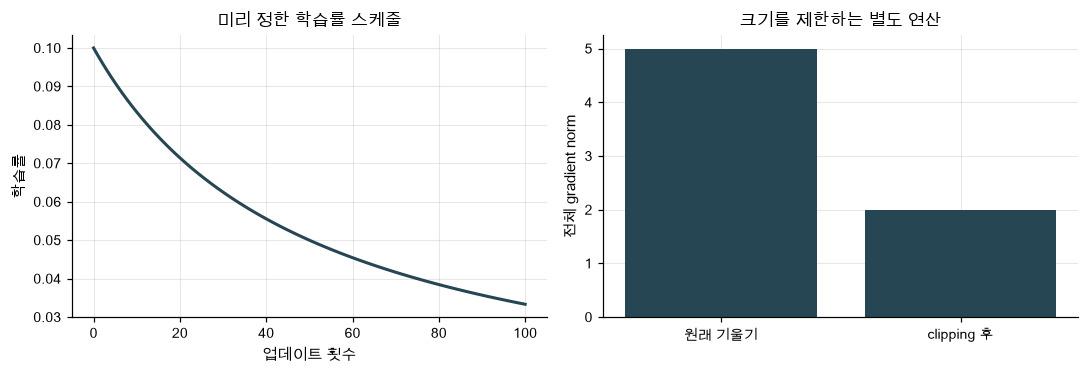

In [50]:
plot_schedule(schedule_steps, rates, np.linalg.norm(large_gradient), np.linalg.norm(clipped))

## ✏️ 10. 직접 채워서 확인합니다

연습은 코딩 테스트처럼 **함수 뼈대가 미리 있고 핵심 한두 줄만 비어 있습니다.**
`raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓴 뒤, 셀을 실행하고 바로 아래 검사 셀을 실행하세요.
아직 채우지 않았으면 안내문만 나오고, 값이 다르면 "손계산과 다릅니다"가 나옵니다. 막히면 그 아래 "정답 보기"를 펼칩니다.

### 연습 A · Momentum 한 스텝 (4절)

상태 처리는 미리 써 두었습니다. 속도를 갱신하는 줄과 파라미터를 갱신하는 줄을 채우세요. $\beta=0.9$입니다.

In [51]:
def exercise_momentum_step(theta, gradient, state, learning_rate, beta=0.9):
    """연습 A: Momentum 한 스텝. theta, gradient: 같은 모양, state: 사전 → (새 θ, {"velocity", "t"})."""
    previous_velocity = state.get("velocity", np.zeros_like(theta))     # 첫 스텝은 0
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: velocity = β·이전 속도 + 기울기, updated = theta − η·velocity
    ### 힌트: 4절의 momentum_step 두 줄입니다. theta를 직접 덮어쓰지 않습니다.
    raise NotImplementedError
    return updated, {"velocity": velocity, "t": state.get("t", 0) + 1}

In [52]:
def check_momentum(candidate):
    """4절의 손계산(두 스텝)과 원본 보존을 검사합니다. 통과하면 메시지를 출력합니다."""
    theta = np.array([1., -2.])
    first, state = candidate(theta, np.array([2., -4.]), {}, 0.1)
    np.testing.assert_allclose(first, [0.8, -1.6])           # 검산: 첫 스텝은 SGD와 같음
    second, state = candidate(first, np.array([-1., 2.]), state, 0.1)
    np.testing.assert_allclose(second, [0.72, -1.44])        # 검산: 4절 손계산
    np.testing.assert_allclose(state["velocity"], [0.8, -1.6])   # 검산: v_2 = 0.9·(2, −4) + (−1, 2)
    assert state["t"] == 2, "두 번 갱신했으므로 t = 2여야 합니다"
    np.testing.assert_array_equal(theta, [1., -2.])          # 검산: 입력 배열은 그대로
    print("Momentum: 두 스텝의 상태와 파라미터가 손계산과 일치합니다.")

run_check(check_momentum, exercise_momentum_step, hint="velocity = beta * previous_velocity + gradient; updated = theta - learning_rate * velocity")

☐ exercise_momentum_step: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: velocity = beta * previous_velocity + gradient; updated = theta - learning_rate * velocity


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
velocity = beta * previous_velocity + gradient
updated = theta - learning_rate * velocity
```

</details>

### ✏️ 연습 B · Adam의 편향 보정 (6절)

이동 평균 두 개와 갱신 줄은 미리 써 두었습니다. 초기 편향을 보정한 $\hat m_t$, $\hat s_t$ 두 줄을 채우세요.
기울기의 부호가 바뀌는 두 번째 스텝과 두 beta가 다른 경우까지 검사합니다.

> **코드** · `candidate(…, **options)`: 사전 `options = {"beta1": 0.5, …}`를 키워드 인자로 펼쳐 넣습니다. `beta1=0.5, beta2=0.5, epsilon=0.0`을 쓴 것과 같습니다.

In [53]:
def exercise_adam_step(theta, gradient, state, learning_rate, beta1=0.9, beta2=0.999, epsilon=1e-8):
    """연습 B: Adam 한 스텝. 모멘트 두 개와 갱신 줄은 미리 있고, 편향 보정 두 줄을 채웁니다. → (새 θ, {"mean", "square", "t"})."""
    t = state.get("t", 0) + 1                                                          # 1부터 세는 업데이트 횟수
    mean = beta1 * state.get("mean", np.zeros_like(theta)) + (1 - beta1) * gradient
    square = beta2 * state.get("square", np.zeros_like(theta)) + (1 - beta2) * gradient ** 2
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: corrected_mean = mean / (1 − β1^t), corrected_square = square / (1 − β2^t)
    ### 힌트: t는 1부터 세는 업데이트 횟수입니다. 6절의 두 줄입니다.
    raise NotImplementedError
    updated = theta - learning_rate * corrected_mean / (np.sqrt(corrected_square) + epsilon)
    return updated, {"mean": mean, "square": square, "t": t}

In [54]:
def check_adam(candidate):
    """6절의 손계산(β = 0.5), 두 β가 다른 경우, 아주 작은 기울기에서 ε의 위치를 검사합니다."""
    options = {"beta1": 0.5, "beta2": 0.5, "epsilon": 0.0}
    first, state = candidate(np.array([1.]), np.array([2.]), {}, 0.1, **options)
    second, state = candidate(first, np.array([-2.]), state, 0.1, **options)
    np.testing.assert_allclose(first, [0.9])                 # 검산: 6절 손계산 t = 1
    np.testing.assert_allclose(second, [14/15])              # 검산: 6절 손계산 t = 2
    np.testing.assert_allclose(state["mean"], [-0.5])        # 검산: m_2 = 0.5·1 + 0.5·(−2)
    np.testing.assert_allclose(state["square"], [3.])        # 검산: s_2 = 0.5·2 + 0.5·4
    assert state["t"] == 2, "두 번 갱신했으므로 t = 2여야 합니다"
    # 서로 다른 beta와 크기가 다른 기울기로 두 이동 평균을 구분합니다.
    options = {"beta1": 0.5, "beta2": 0.75, "epsilon": 0.0}
    first, state = candidate(np.array([1.]), np.array([2.]), {}, 0.1, **options)
    np.testing.assert_allclose(state["square"], [1.])        # 검산: s_1 = 0.25·4
    second, state = candidate(first, np.array([1.]), state, 0.1, **options)
    np.testing.assert_allclose(state["mean"], [1.])          # 검산: m_2 = 0.5·1 + 0.5·1
    np.testing.assert_allclose(state["square"], [1.])        # 검산: s_2 = 0.75·1 + 0.25·1
    np.testing.assert_allclose(second, [0.9 - np.sqrt(7)/30])   # 검산: m̂ = 1/0.75, ŝ = 1/(1 − 0.75²) → 0.1·(4/3)/√(16/7)
    # 작은 기울기에서는 epsilon의 위치가 관측 가능한 차이를 만듭니다.
    tiny_step, _ = candidate(np.array([1.]), np.array([1e-8]), {}, 0.1, epsilon=1e-8)
    np.testing.assert_allclose(tiny_step, [0.95])            # 검산: m̂/(√ŝ + ε) = 1e−8/(1e−8 + 1e−8) = 0.5
    print("Adam: 두 모멘트·편향 보정·스텝 수·epsilon 위치가 손계산과 일치합니다.")

run_check(check_adam, exercise_adam_step, hint="corrected_mean = mean / (1 - beta1 ** t); corrected_square = square / (1 - beta2 ** t)")

☐ exercise_adam_step: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: corrected_mean = mean / (1 - beta1 ** t); corrected_square = square / (1 - beta2 ** t)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
corrected_mean = mean / (1 - beta1 ** t)
corrected_square = square / (1 - beta2 ** t)
```

</details>

### ✏️ 연습 C · gradient clipping (9절)

기울기의 norm이 `maximum_norm`보다 크면 방향은 두고 크기만 줄입니다. 곱할 배율 `scale` 한 줄을 채우세요.

In [55]:
def exercise_clip_global_norm(gradient, maximum_norm):
    """연습 C: gradient clipping. gradient: 어떤 모양, maximum_norm: 양수 → 같은 모양."""
    assert maximum_norm > 0, "최대 norm은 양수여야 합니다"
    norm = np.linalg.norm(gradient)                # ‖g‖₂
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: norm이 maximum_norm 이하이면 1.0, 크면 maximum_norm / norm 인 scale
    ### 힌트: 조건식 하나로 씁니다. 9절의 clip_global_norm과 같습니다.
    raise NotImplementedError
    return gradient * scale

In [56]:
def check_clip(candidate):
    """큰 기울기·작은 기울기·0 기울기 세 경우로 검사합니다. 통과하면 메시지를 출력합니다."""
    np.testing.assert_allclose(candidate(np.array([3., 4.]), 2.0), [1.2, 1.6])          # 검산: 크기 5 → 2, 방향 그대로
    np.testing.assert_array_equal(candidate(np.array([0.3, 0.4]), 2.0), [0.3, 0.4])   # 검산: 작은 기울기는 그대로
    np.testing.assert_array_equal(candidate(np.zeros(2), 2.0), [0., 0.])              # 검산: 0 기울기는 0/0 없이 그대로
    print("clipping: 크기 5인 기울기가 2로 줄고 방향은 같습니다.")

run_check(check_clip, exercise_clip_global_norm, hint="scale = 1.0 if norm <= maximum_norm else maximum_norm / norm")

☐ exercise_clip_global_norm: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: scale = 1.0 if norm <= maximum_norm else maximum_norm / norm


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
scale = 1.0 if norm <= maximum_norm else maximum_norm / norm
```

</details>

### 🔍 완성 예제 · 배치 크기를 바꾸고 비교 단위를 설명하기

배치를 16에서 8로 바꾸면 65개 표본을 한 번 사용하는 데 5회 대신 9회 업데이트가 필요합니다. 같은 40에폭은 같은 표본 처리량이지만 업데이트 횟수는 다릅니다.
아래를 실행한 뒤 배치 크기를 32 또는 65로 바꾸고 `state['t']`, `history['seen'][-1]`과 손실을 비교하세요.

In [57]:
# 쓰는 것: x_train, features, targets, initial_theta, train_regression (8절) · epoch_batches (2절) · adam_step (6절)
smaller_schedule = []                                                   # 40에폭 × (65개를 8개씩 → 9배치)
rng_smaller = np.random.default_rng(42)
for epoch in range(40):
    smaller_schedule.extend(epoch_batches(len(x_train), 8, rng_smaller))
small_batch_theta, small_batch_state, small_batch_history = train_regression(
    features, targets, initial_theta, smaller_schedule, adam_step, 0.05)
assert small_batch_state["t"] == 9*40, "배치 8이면 에폭당 9스텝 × 40에폭이어야 합니다"
assert small_batch_history["seen"][-1] == 65*40, "처리한 표본 수는 배치 크기와 무관하게 65 × 40이어야 합니다"
print("배치 8: steps", small_batch_state["t"], "seen", small_batch_history["seen"][-1],
      "loss", small_batch_history["loss"][-1])

배치 8: steps 360 seen 2600 loss 0.0059336630146475545


### ✏️ 준비도 질문 · 다음으로 가기 전, 네 가지를 따로 확인합니다

🔑 표시가 붙은 절의 내용만으로 답할 수 있어야 합니다.

- **설명:** loss·backward·optimizer·예측이 각각 무엇을 계산하는지 구분할 수 있나요? → 1·3절
- **수식:** Momentum·RMSProp·Adam을 두 스텝 펼쳐 쓰고, 평균·제곱 평균·편향 보정의 차이를 말할 수 있나요? → 4–6절
- **구현:** 상태를 밖에 유지하고, 마지막 작은 배치에서도 올바른 평균을 내며 갱신할 수 있나요? → 2·8·10절
- **변형:** 배치 크기·학습률·초기화를 바꾸었을 때 비교할 조건과 기록할 값을 정했나요? → 7–10절

이제 공통 기초에서 **계산 구조 → 관측 모형과 목적 → 미분 → 업데이트**를 한 번씩 연결했습니다.
다음 학습 단위는 [전체 경로](../../docs/CURRICULUM.md)의 05 CNN입니다. 지역 연결과 가중치 공유를 배열 연산으로 옮기게 됩니다.

📎 참고: [Hinton 강의의 미니배치·Momentum·RMSProp](https://www.cs.toronto.edu/~tijmen/csc321/slides/lecture_slides_lec6.pdf), [Adam 원 논문](https://arxiv.org/abs/1412.6980).
목적·초기값·시드·스텝·학습률은 위 코드에 명시했고 수치는 직접 실행한 결과입니다.